# Regresja liniowa

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

LEAGUE = "premier_league"          
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
# LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"


EXPERIMENT = "linear_regression"

DATA_DIR = Path("../data/processed")

DATA_PATH = DATA_DIR / LEAGUE / f"{LEAGUE}_features.csv"
RESULTS_PATH = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)


MIN_MATCHES = 10

def save_plot(filename):
    plt.savefig(
        RESULTS_PATH / filename,
        dpi=150,
        bbox_inches="tight"
    )

def save_df(df, filename):
    df.to_csv(RESULTS_PATH / filename, index=False)

def close_plot():
    plt.close()
    
    

def plot_and_save_class_distribution(
    y_true_cls,
    y_pred_cls,
    option_suffix,      
    filename_prefix    
):
    """
    y_true_cls : lista klas ["H","D","A"] lub ["0","1"] itp.
    y_pred_cls : lista klas
    """

    df_counts = (
        pd.DataFrame({
            "True": y_true_cls,
            "Pred": y_pred_cls
        })
        .melt(var_name="Type", value_name="Class")
        .value_counts()
        .reset_index(name="Count")
    )


    df_true = df_counts[df_counts["Type"] == "True"][["Class","Count"]] \
        .rename(columns={"Count":"True_Count"})
    df_pred = df_counts[df_counts["Type"] == "Pred"][["Class","Count"]] \
        .rename(columns={"Count":"Pred_Count"})

    df_final = (
        pd.merge(df_true, df_pred, on="Class", how="outer")
        .fillna(0)
        .sort_values("Class")
    )


    save_df(
        df_final,
        f"{filename_prefix}_{option_suffix}.csv"
    )


    x = np.arange(len(df_final))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, df_final["True_Count"], width, label="True")
    plt.bar(x + width/2, df_final["Pred_Count"], width, label="Pred")

    plt.xticks(x, df_final["Class"])
    plt.ylabel("Liczba meczów")
    plt.title(f"Rozkład klas —  {option_suffix}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{filename_prefix}_{option_suffix}.png")
    plt.show()
    close_plot()

    return df_final

LEAGUES_DICT = {
    "premier_league": "Premier League",
    "serie_a": "Serie A",
    "la_liga": "La Liga",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
    "all_leagues": "All Leagues"
}

current_league_name = LEAGUES_DICT[LEAGUE]


In [2]:
from sklearn.metrics import classification_report

def save_classification_report(
    y_true_cls,
    y_pred_cls,
    model_name,
    option,
    filename,
    split_date
):
    report = classification_report(
        y_true_cls,
        y_pred_cls,
        output_dict=True
    )

    df_report = (
        pd.DataFrame(report)
        .T
        .reset_index()
        .rename(columns={"index": "Class"})
    )

    df_report["Model"] = model_name
    df_report["League"] = LEAGUE
    df_report["Experiment"] = "linear_regression"
    df_report["Option"] = option
    df_report["SplitDate"] = split_date

    save_df(df_report, filename)


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 113)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,14.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,2.0,2.0,D,11.0,13.0,3.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,1.0,2.0,A,14.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [4]:
# drugi zestaw cech

# cols_to_exclude = {
#     # meta / identyfikatory
#     "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

#     # wynikowe i bieżące statystyki meczu (niedostępne przed meczem)
#     "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
#     "GoalDiff", "TotalGoals",
#     "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
#     "HY", "AY", "HR", "AR",

#     # NOWE — usuwamy nadmiarowe prawdopodobieństwa, które psują regresję
#     "Prob_D_b365", "Prob_A_b365"
# }

In [5]:
target = "FTR"
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}


candidate_cols = [c for c in df.columns if c not in cols_to_exclude]


keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend", "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

print(f"Liczba wybranych cech: {len(X_features)}")
X_features[:10]

Liczba wybranych cech: 37


['Prob_H_b365',
 'Home_GF_last5',
 'Home_GA_last5',
 'Home_GD_last5',
 'Home_Pts_last5',
 'Home_Pts_last10',
 'Home_Pts_trend_3v10',
 'Away_GF_last5',
 'Away_GA_last5',
 'Away_GD_last5']

In [6]:
#display(X_features)
#display(X[X_features].isna().sum().sort_values(ascending=False))

## Braki danych w finalnym zbiorze cech

W finalnym zestawie cech **nie uwzględniono zmiennych o bardzo dużym odsetku braków** (ok. 44%), takich jak kursy i agregaty BetBrain (`BbMx*`, `BbAv*`, `Bb1X2`), które występowały głównie w starszych sezonach i mogłyby wprowadzać niestabilność modelu.  

Pozostałe braki danych dotyczą wyłącznie cech opartych o **formę drużyn (rolling windows)** oraz **statystyki sezonowe**. Są one naturalną konsekwencją pierwszych kolejek sezonu, w których nie istnieje jeszcze historia wcześniejszych meczów, z której można obliczyć średnie i trendy.  

Braki te są **oczekiwane, niewielkie procentowo** i zostały obsłużone na etapie modelowania (imputacja medianą), dzięki czemu nie wpływają negatywnie na poprawność ani stabilność uczenia modeli.


In [7]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y = le.fit_transform(df[target])

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test  = y[test_mask]

X_train.shape, X_test.shape, len(y_train), len(y_test)

((2660, 37), (760, 37), 2660, 760)

In [8]:
from sklearn.metrics import root_mean_squared_error, confusion_matrix
from sklearn.metrics import r2_score, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Kodowanie celu (OPCJA A)
encoding = {"A": -1, "D": 0, "H": 1}
y = df[target].map(encoding).values



split_date = pd.Timestamp("2022-07-01")

train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test  = y[test_mask]

X_train.shape, X_test.shape


def regress_to_class(y_pred):
    return np.digitize(y_pred, bins=[-0.5, 0.5])


def evaluate_regression_model(name, y_test, y_pred):
    print(f"\n==================== {name} ====================")

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    y_pred = regress_to_class(y_pred) 


    mapping_true = {-1:"A", 0:"D", 1:"H"}
    y_test_cls = [mapping_true[v] for v in y_test]


    mapping_pred = {0:"A", 1:"D", 2:"H"}
    y_pred_cls = [mapping_pred[v] for v in y_pred]


    acc = accuracy_score(y_test_cls, y_pred_cls)
    f1m = f1_score(y_test_cls, y_pred_cls, average="macro")
    print(f"Accuracy (po mapowaniu): {acc:.4f}")
    print(f"Macro-F1 (po mapowaniu): {f1m:.4f}")


    cm = confusion_matrix(y_test_cls, y_pred_cls)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["A", "D", "H"], yticklabels=["A", "D", "H"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} - Confusion Matrix")
    save_plot(f"{name} - Confusion Matrix.png")
    plt.show()   
    close_plot()
    save_classification_report(
        y_test_cls,
        y_pred_cls,
        model_name=name,
        option="A",
        filename=f"{name.replace(' ', '_').lower()}_classification_report_A.csv",
        split_date=split_date
    )

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro-F1": f1m,
        "League": LEAGUE,
        "Experiment": "linear_regression",
        "Option": "Outcome Regression",
        "RMSE": rmse,
        "R²": r2,
        "SplitDate": split_date,
        "N_test": len(y_test)
    }



def make_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

Training RMSE: 0.7695

==================== Linear Regression ====================
RMSE: 0.7770
R²:   0.1947
Accuracy (po mapowaniu): 0.3934
Macro-F1 (po mapowaniu): 0.3868


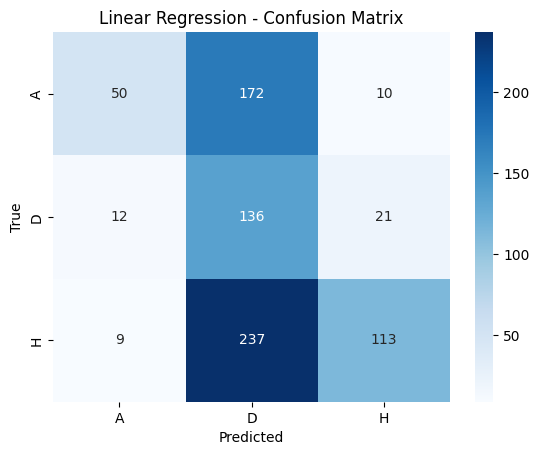

In [9]:
from sklearn.linear_model import LinearRegression


results = []

linear = LinearRegression(n_jobs=-1)
pipe_linear = make_pipeline(linear)
pipe_linear.fit(X_train, y_train)

y_pred = pipe_linear.predict(X_train)
rmse_score = root_mean_squared_error(y_train, y_pred)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred = pipe_linear.predict(X_test)
results.append(evaluate_regression_model("Linear Regression", y_test, y_pred))

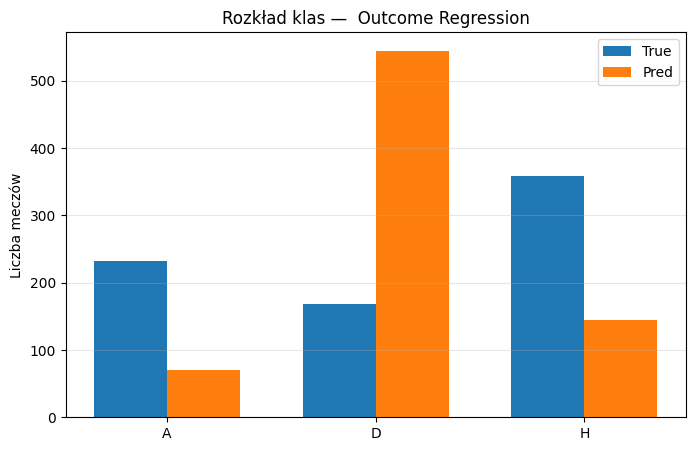

,Class,True_Count,Pred_Count
0,A,232,71
1,D,169,545
2,H,359,144


In [10]:
# ===== OPCJA A — ROZKŁAD KLAS =====

mapping_true = {-1:"A", 0:"D", 1:"H"}
mapping_pred = {0:"A", 1:"D", 2:"H"}

y_true_cls_A = [mapping_true[v] for v in y_test]
y_pred_cls_A = [mapping_pred[v] for v in regress_to_class(
    pipe_linear.predict(X_test)
)]

plot_and_save_class_distribution(
    y_true_cls_A,
    y_pred_cls_A,
    option_suffix="Outcome Regression",
    filename_prefix="class_distribution"
)


In [11]:
from sklearn.metrics import classification_report


report_lin = classification_report(
    y_true_cls_A,
    y_pred_cls_A,
    labels=["A", "D", "H"],
    output_dict=True
)

df_report_lin = pd.DataFrame(report_lin).T
df_report_lin["Model"] = "Linear Regression - Outcome Regression"
df_report_lin["League"] = LEAGUE
df_report_lin["SplitDate"] = split_date
df_report_lin["N_train"] = len(y_train)
df_report_lin["N_test"] = len(y_test)

display(df_report_lin)


,precision,recall,f1-score,support,Model,League,SplitDate,N_train,N_test
A,0.704225,0.215517,0.330033,232.000000,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760
D,0.249541,0.804734,0.380952,169.000000,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760
H,0.784722,0.314763,0.449304,359.000000,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760
accuracy,0.393421,0.393421,0.393421,0.393421,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760
macro avg,0.579496,0.445005,0.386763,760.000000,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760
weighted avg,0.641142,0.393421,0.397696,760.000000,Linear Regression - Outcome Regression,premier_league,2022-07-01,2660,760


C:\Users\tdroz\AppData\Local\Temp\ipykernel_20244\1498945976.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


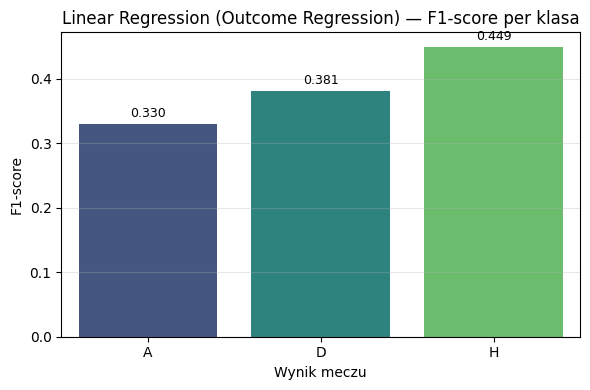

In [12]:
df_f1_class_lin = (
    df_report_lin
    .loc[["A", "D", "H"], ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_lin,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Linear Regression (Outcome Regression) — F1-score per klasa")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


W przypadku regresji liniowej wartości F1-score dla poszczególnych klas
zostały wyznaczone po mapowaniu wyników regresji na klasy dyskretne,
co umożliwia bezpośrednie porównanie jakości predykcji z modelami
klasyfikacyjnymi.

## Baseline - zawsze H - porównanie

BASELINE vs MODEL — Linear Regression


,Metric,Baseline_HomeWin,Linear_Regression,Gain_vs_Baseline
0,Accuracy,0.472368,0.393421,-0.078947
1,Macro-F1,0.213881,0.386763,0.172882


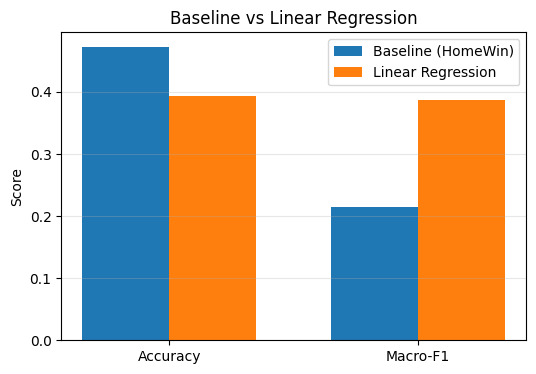

In [13]:

# BASELINE NAIWNA vs MODEL — Linear Regression
# (zawsze HomeWin)

mapping_true = {-1: "A", 0: "D", 1: "H"}
mapping_pred = {0: "A", 1: "D", 2: "H"}

y_test_cls = [mapping_true[v] for v in y_test]


y_naive = ["H"] * len(y_test_cls)

acc_naive = accuracy_score(y_test_cls, y_naive)
f1_naive  = f1_score(y_test_cls, y_naive, average="macro")


y_pred = pipe_linear.predict(X_test)
y_pred_cls = [mapping_pred[v] for v in regress_to_class(y_pred)]

acc_model = accuracy_score(y_test_cls, y_pred_cls)
f1_model  = f1_score(y_test_cls, y_pred_cls, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Linear_Regression": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

print("BASELINE vs MODEL — Linear Regression")
display(df_baseline_compare)


save_df(df_baseline_compare, "baseline_vs_linear_regression.csv")

plt.figure(figsize=(6,4))

x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive],
        width, label="Baseline (HomeWin)")
plt.bar(x + width/2, [acc_model, f1_model],
        width, label="Linear Regression")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Linear Regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)


save_plot("baseline_vs_linear_regression.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_20244\1096548417.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


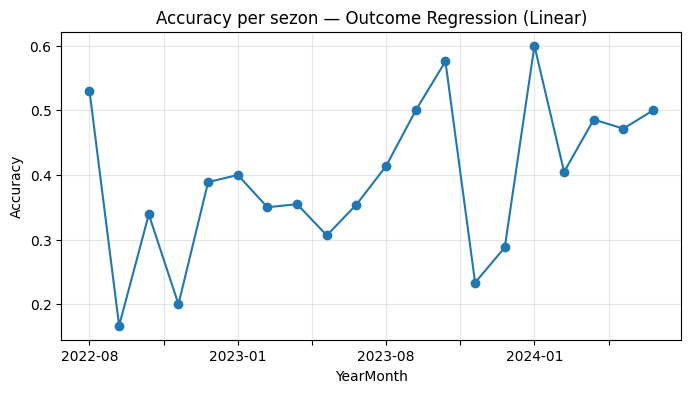

In [14]:

# STABILNOŚĆ W CZASIE — OPCJA A (per sezon)

mapping_true = {-1: "A", 0: "D", 1: "H"}
mapping_pred = {0: "A", 1: "D", 2: "H"}

y_pred_A = pipe_linear.predict(X_test)
y_pred_cls_A = [mapping_pred[v] for v in regress_to_class(y_pred_A)]
y_true_cls_A = [mapping_true[v] for v in y_test]

df_eval_A = df.loc[test_mask, ["Season", "Date"]].copy()
df_eval_A["y_true"] = y_true_cls_A
df_eval_A["y_pred"] = y_pred_cls_A

df_eval_A["YearMonth"] = df_eval_A["Date"].dt.to_period("M").astype(str)
acc_per_season_A = (
    df_eval_A
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_linear_A = (
    acc_per_season_A
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_linear_A["Model"] = "Linear Regression (Outcome Regression)"

df_acc_linear_A.to_csv(
    RESULTS_PATH / "accuracy_per_month_linear_A.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_season_A.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy per sezon — Outcome Regression (Linear)")
plt.grid(alpha=0.3)

save_plot("accuracy_per_season_A.png")
plt.show()
close_plot()


{'model__alpha': 350}
Best RMSE (CV): 0.7780

==================== Ridge Regression ====================
RMSE: 0.7755
R²:   0.1979
Accuracy (po mapowaniu): 0.3882
Macro-F1 (po mapowaniu): 0.3809


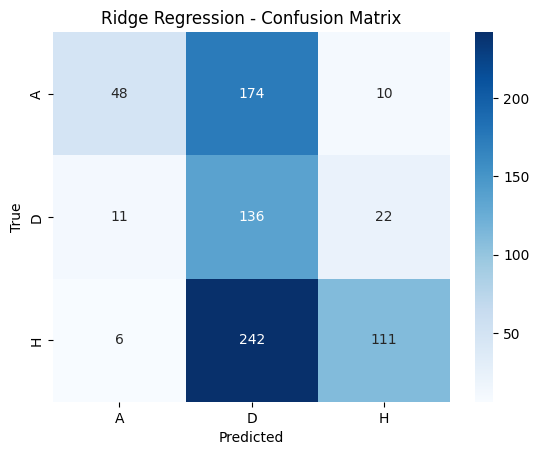

In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV


param_grid = {
    "model__alpha": [250, 300, 350, 400, 500]
}
ridge = Ridge()
pipe_ridge = make_pipeline(ridge)
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

print(grid_ridge.best_params_)
print(f"Best RMSE (CV): {-grid_ridge.best_score_:.4f}")

y_pred = grid_ridge.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Ridge Regression", y_test, y_pred))

{'model__alpha': 0.019}
Best RMSE (CV): 0.7764

==================== Lasso Regression ====================
RMSE: 0.7725
R²:   0.2040
Accuracy (po mapowaniu): 0.3671
Macro-F1 (po mapowaniu): 0.3558


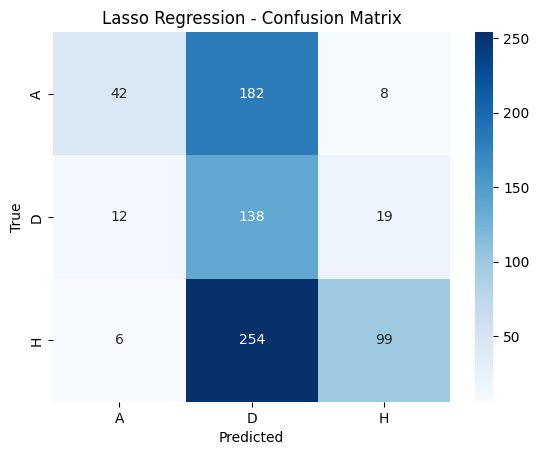

In [16]:
from sklearn.linear_model import Lasso


param_grid = {
    "model__alpha": [0.001, 0.01, 0.017, 0.018, 0.019, 0.05, 0.1]
}
lasso = Lasso()
pipe_lasso = make_pipeline(lasso)
grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)

print(grid_lasso.best_params_)
print(f"Best RMSE (CV): {-grid_lasso.best_score_:.4f}")

y_pred = grid_lasso.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Lasso Regression", y_test, y_pred))

{'model__alpha': 0.02, 'model__l1_ratio': 0.95}
Best RMSE (CV): 0.7764

==================== Elastic Net Regression ====================
RMSE: 0.7725
R²:   0.2040
Accuracy (po mapowaniu): 0.3658
Macro-F1 (po mapowaniu): 0.3545


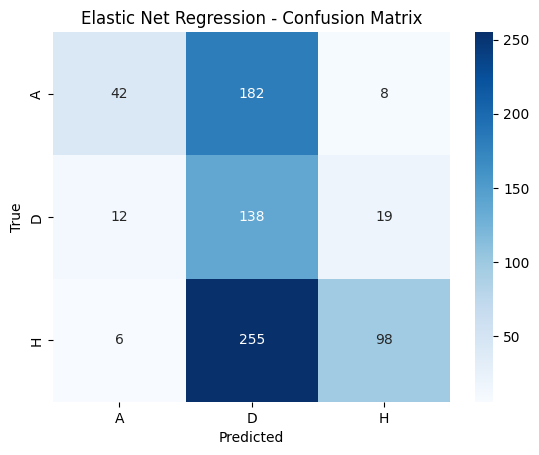

In [17]:
from sklearn.linear_model import ElasticNet

param_grid = {
    "model__alpha": [0.005, 0.01, 0.02, 0.03, 0.1],
    "model__l1_ratio": [0.80, 0.85, 0.90, 0.95, 1]
}
elastic_net = ElasticNet()
pipe_elastic_net = make_pipeline(elastic_net)
grid_elastic_net = GridSearchCV(
    pipe_elastic_net,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net.fit(X_train, y_train)

print(grid_elastic_net.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net.best_score_:.4f}")

y_pred = grid_elastic_net.best_estimator_.predict(X_test)
results.append(evaluate_regression_model("Elastic Net Regression", y_test, y_pred))

In [18]:
df_results = pd.DataFrame(results)
save_df(df_results, "linear_regression_opcja_A.csv")
display(df_results)
print("\n===== PODSUMOWANIE MODELI REGRESYJNYCH =====")
display(df_results)

,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
0,Linear Regression,0.393421,0.386763,premier_league,linear_regression,Outcome Regression,0.777008,0.194698,2022-07-01,760
1,Ridge Regression,0.388158,0.380906,premier_league,linear_regression,Outcome Regression,0.775481,0.197860,2022-07-01,760
2,Lasso Regression,0.367105,0.355795,premier_league,linear_regression,Outcome Regression,0.772512,0.203989,2022-07-01,760
3,Elastic Net Regression,0.365789,0.354533,premier_league,linear_regression,Outcome Regression,0.772514,0.203986,2022-07-01,760



===== PODSUMOWANIE MODELI REGRESYJNYCH =====


,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
0,Linear Regression,0.393421,0.386763,premier_league,linear_regression,Outcome Regression,0.777008,0.194698,2022-07-01,760
1,Ridge Regression,0.388158,0.380906,premier_league,linear_regression,Outcome Regression,0.775481,0.197860,2022-07-01,760
2,Lasso Regression,0.367105,0.355795,premier_league,linear_regression,Outcome Regression,0.772512,0.203989,2022-07-01,760
3,Elastic Net Regression,0.365789,0.354533,premier_league,linear_regression,Outcome Regression,0.772514,0.203986,2022-07-01,760


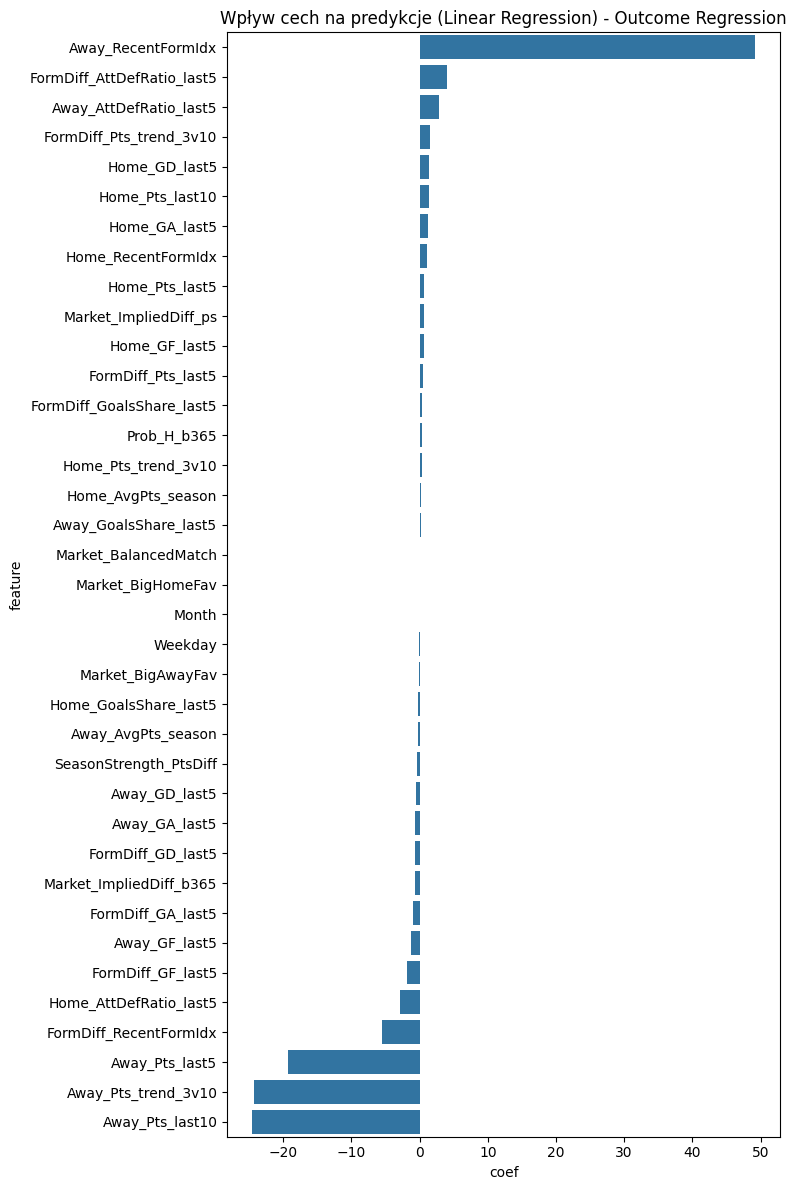

In [19]:
coefs = pipe_linear.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
name = "Wpływ cech na predykcje (Linear Regression) - Outcome Regression"
plt.title(name)
plt.tight_layout()

save_plot(f"{name}.png")
plt.show()
close_plot()


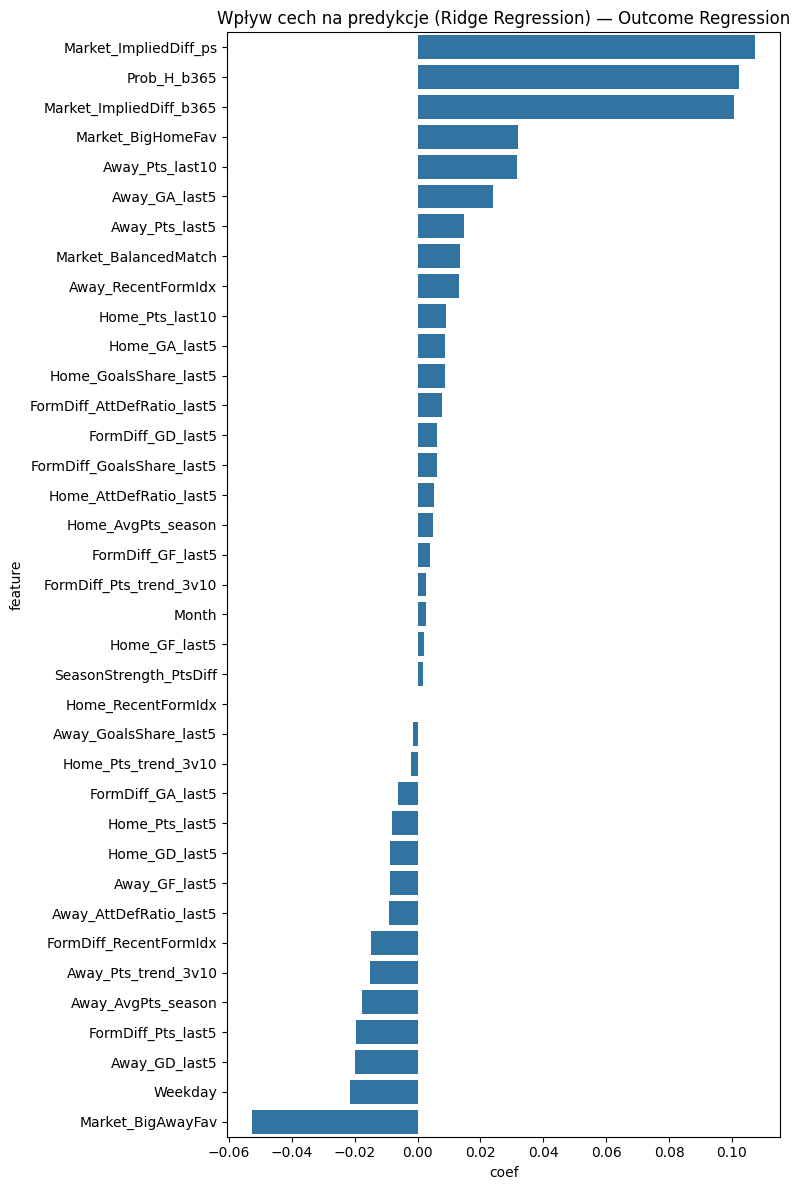

In [20]:
coefs = grid_ridge.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Ridge Regression) — Outcome Regression")
plt.tight_layout()

save_plot("Wpływ cech na predykcje (Ridge Regression) — Opcja A.png")
plt.show()
close_plot()

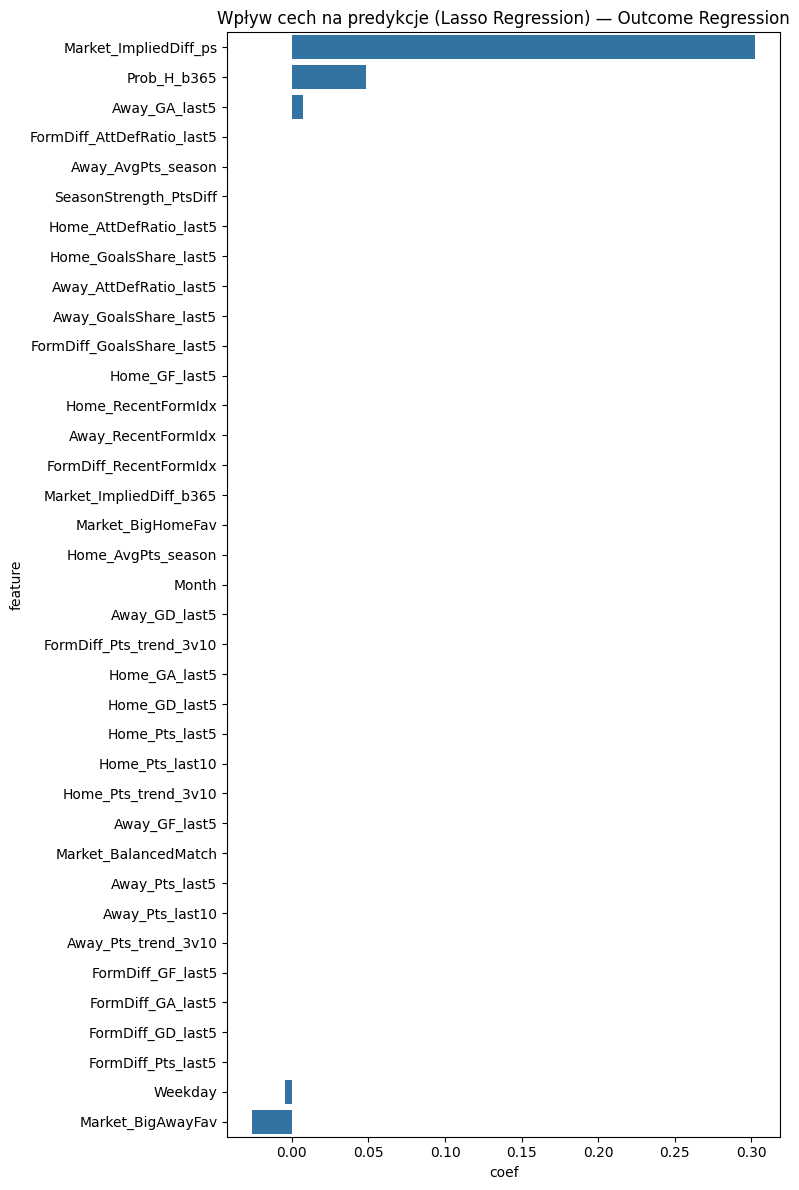

In [21]:
coefs = grid_lasso.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Lasso Regression) — Outcome Regression")
plt.tight_layout()


save_plot("Wpływ cech na predykcje (Lasso Regression) — Opcja A.png")
plt.show()
close_plot()

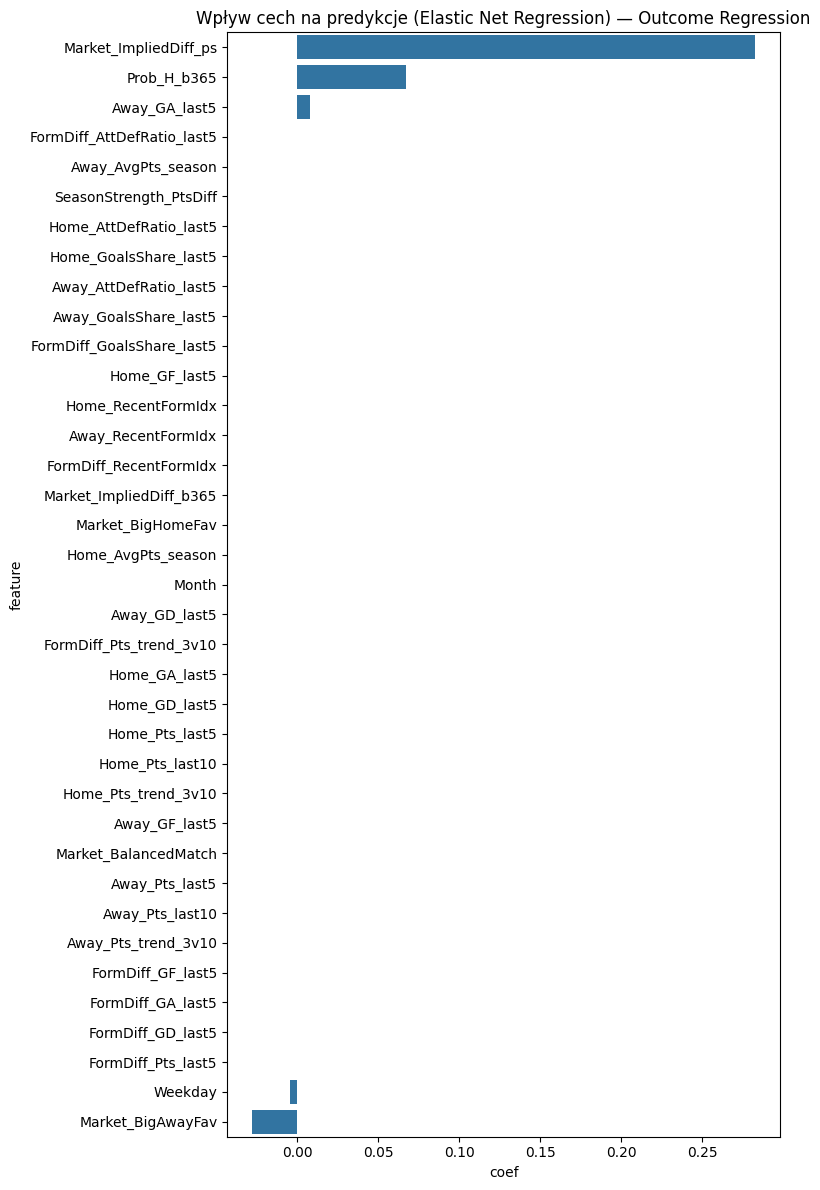

In [22]:
coefs = grid_elastic_net.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) — Outcome Regression")
plt.tight_layout()


save_plot("Wpływ cech na predykcje (Elastic Net Regression) — Opcja A.png")
plt.show()
close_plot()

## Porównania metod: 


### Tabela zbiorcza (RMSE, R², Accuracy, Macro-F1)

In [23]:
# sortowanie po Macro-F1 
df_results_sorted = df_results.sort_values("Macro-F1", ascending=False)

display(df_results_sorted)

save_df(df_results_sorted, "linear_models_comparison_summary.csv")


,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
0,Linear Regression,0.393421,0.386763,premier_league,linear_regression,Outcome Regression,0.777008,0.194698,2022-07-01,760
1,Ridge Regression,0.388158,0.380906,premier_league,linear_regression,Outcome Regression,0.775481,0.197860,2022-07-01,760
2,Lasso Regression,0.367105,0.355795,premier_league,linear_regression,Outcome Regression,0.772512,0.203989,2022-07-01,760
3,Elastic Net Regression,0.365789,0.354533,premier_league,linear_regression,Outcome Regression,0.772514,0.203986,2022-07-01,760


###  Accuracy vs Macro-F1 (porównanie metod)

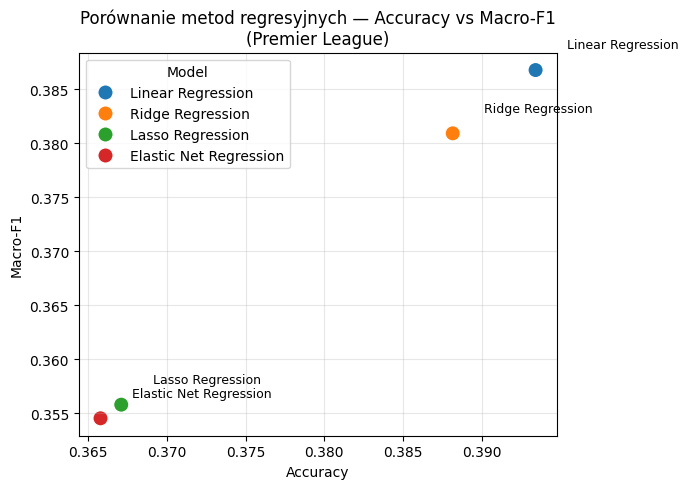

In [24]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=df_results,
    x="Accuracy",
    y="Macro-F1",
    hue="Model",
    s=120
)

for _, row in df_results.iterrows():
    ax.text(
        row["Accuracy"] + 0.002,
        row["Macro-F1"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.title(f"Porównanie metod regresyjnych — Accuracy vs Macro-F1\n({current_league_name})")
plt.grid(alpha=0.3)
plt.tight_layout()

save_plot("linear_models_accuracy_vs_macro_f1.png")
plt.show()
close_plot()


### Ranking metod regresyjnych — Accuracy vs Macro-F1

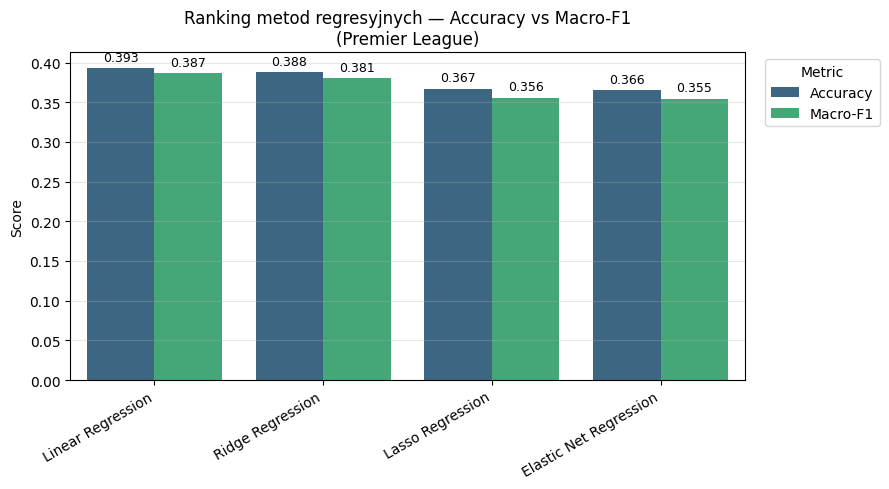

In [25]:

# RANKING METOD REGRESYJNYCH
# Accuracy vs Macro-F1

df_rank = df_results.sort_values("Macro-F1", ascending=False)


df_rank_melted = df_rank.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro-F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_rank_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.title(f"Ranking metod regresyjnych — Accuracy vs Macro-F1\n({current_league_name})")
plt.ylabel("Score")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
save_plot("linear_models_accuracy_vs_macro_f1_ranking.png")
plt.show()
close_plot()


## 4.2. Model OPCJA B — Regresja GoalDiff i mapowanie na klasy H/D/A

W klasycznym podejściu (Outcome Regression) model próbuje bezpośrednio przewidywać
kategorię wyniku meczu (H – wygrana gospodarzy, D – remis, A – wygrana gości).
Jest to jednak zadanie trudne dla modeli liniowych, ponieważ klasy są
dyskretne i nieliniowo separowalne.

Aby uzyskać bardziej stabilne wyniki, wprowadzono alternatywne podejście:

**GoalDiff Regression — przewidywanie różnicy bramek (GoalDiff) jako zmiennej ciągłej,  
a następnie mapowanie wartości regresji na klasy H/D/A.**

Różnica bramek definiowana jest jako:

\[
GoalDiff = FTHG - FTAG
\]

gdzie:  
- *FTHG* – liczba bramek gospodarzy,  
- *FTAG* – liczba bramek gości.

Model regresyjny przewiduje wartość ciągłą `GoalDiff`, a następnie jest ona
mapowana na klasy:

- `A` – jeśli przewidywany GoalDiff < –0.5  
- `D` – jeśli –0.5 ≤ GoalDiff ≤ +0.5  
- `H` – jeśli GoalDiff > +0.5  

Takie podejście lepiej wykorzystuje właściwości modeli liniowych,
ponieważ różnica bramek jest zmienną ciągłą, a nie kategorią.  
W efekcie modele uczą się uporządkowanej struktury wyniku zamiast próbować
bezpośrednio zgadywać jedną z trzech nieuporządkowanych klas.



In [26]:

# OPCJA B — REGRESJA NA GOALDIFF + MAPOWANIE NA KLASY H/D/A


print("\n\n###########################################")
print("##########   GoalDiff Regression   #########")
print("##########   REGRESJA GOALDIFF    #########")
print("###########################################\n")



df["GoalDiff_reg"] = df["FTHG"] - df["FTAG"] # <- TARGET OPCJI B
yB = df["GoalDiff_reg"].values


X_train_B = X.loc[train_mask].reset_index(drop=True)
X_test_B  = X.loc[test_mask].reset_index(drop=True)
y_train_B = yB[train_mask]
y_test_B  = yB[test_mask]


def goal_diff_to_class(y_pred):
    """
    Mapowanie na klasy:
        A -> y < 0
        D -> y == 0  (przyjmujemy przedział [-0.5, +0.5])
        H -> y > 0
    """
    classes = []
    for v in y_pred:
        if v < -0.5:
            classes.append("A")
        elif v > 0.5:
            classes.append("H")
        else:
            classes.append("D")
    return classes



def evaluate_opcjaB(name, y_test, y_pred_cont):
    print(f"\n==================== {name} GoalDiff Regression ====================")


    rmse = root_mean_squared_error(y_test, y_pred_cont)
    r2   = r2_score(y_test, y_pred_cont)
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    y_pred_cls = goal_diff_to_class(y_pred_cont)
    y_test_cls = []
    for v in y_test:
        if v < 0:
            y_test_cls.append("A")
        elif v > 0:
            y_test_cls.append("H")
        else:
            y_test_cls.append("D")

    acc = accuracy_score(y_test_cls, y_pred_cls)
    f1m = f1_score(y_test_cls, y_pred_cls, average="macro")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1m:.4f}")

    cm = confusion_matrix(y_test_cls, y_pred_cls, labels=["A","D","H"])
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=["A","D","H"], yticklabels=["A","D","H"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} — Confusion Matrix (GoalDiff Regression)")
    
    
    save_plot(f"{name} - Confusion Matrix_B.png")
    plt.show()
    close_plot()
    save_classification_report(
        y_test_cls,
        y_pred_cls,
        model_name=name,
        option="B",
        filename=f"{name.replace(' ', '_').lower()}_classification_report_B.csv",
        split_date=split_date
    )

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro-F1": f1m,
        "League": LEAGUE,
        "Experiment": "linear_regression",
        "Option": "GoalDiff Regression",
        "RMSE": rmse,
        "R²": r2,
        "SplitDate": split_date,
        "N_test": len(y_test)
    }



###########################################
##########   GoalDiff Regression   #########
##########   REGRESJA GOALDIFF    #########
###########################################



Training RMSE: 1.6096

==================== Linear Regression GoalDiff Regression ====================
RMSE: 1.7474
R²:   0.2230
Accuracy: 0.5053
Macro-F1: 0.4850


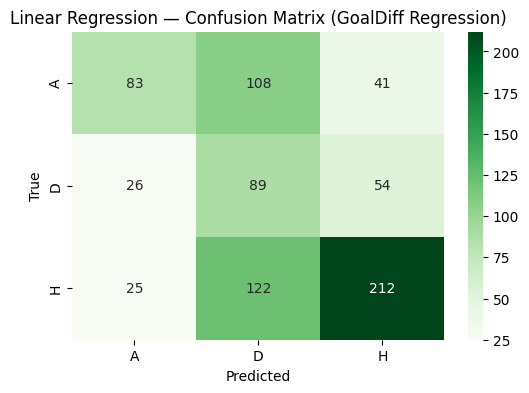

In [27]:

# 6. Modele jak w Opcji A

results_B = []

linear_B = LinearRegression(n_jobs=-1)
pipe_linear_B = make_pipeline(linear_B)
pipe_linear_B.fit(X_train_B, y_train_B)

y_pred_B = pipe_linear_B.predict(X_train_B)
rmse_score = root_mean_squared_error(y_train_B, y_pred_B)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred_B = pipe_linear_B.predict(X_test_B)
results_B.append(evaluate_opcjaB("Linear Regression", y_test_B, y_pred_B))

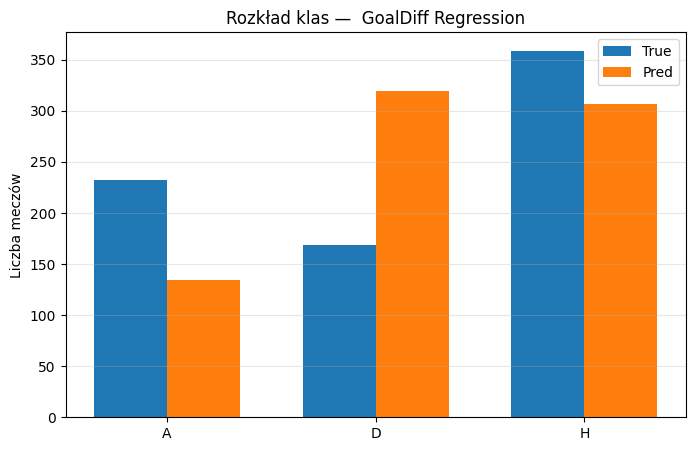

,Class,True_Count,Pred_Count
0,A,232,134
1,D,169,319
2,H,359,307


In [28]:
# ===== OPCJA B — ROZKŁAD KLAS =====

y_pred_cls_B = goal_diff_to_class(y_pred_B)

y_true_cls_B = []
for v in y_test_B:
    if v < 0:
        y_true_cls_B.append("A")
    elif v > 0:
        y_true_cls_B.append("H")
    else:
        y_true_cls_B.append("D")

plot_and_save_class_distribution(
    y_true_cls_B,
    y_pred_cls_B,
    option_suffix="GoalDiff Regression",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Linear_Model,Gain_vs_Baseline
0,Accuracy,0.472368,0.505263,0.032895
1,Macro-F1,0.213881,0.484981,0.271099


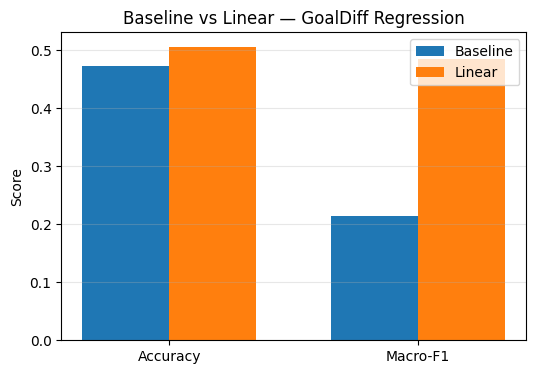

In [29]:

# BASELINE vs LINEAR — OPCJA B

y_true_cls = []
for v in y_test_B:
    if v < 0:
        y_true_cls.append("A")
    elif v > 0:
        y_true_cls.append("H")
    else:
        y_true_cls.append("D")


y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")


y_pred = pipe_linear_B.predict(X_test_B)
y_pred_cls = goal_diff_to_class(y_pred)

acc_model = accuracy_score(y_true_cls, y_pred_cls)
f1_model  = f1_score(y_true_cls, y_pred_cls, average="macro")


df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Linear_Model": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

display(df_baseline_compare)
save_df(df_baseline_compare, "baseline_vs_linear.csv")


plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Linear")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Linear — GoalDiff Regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_linear.png")
plt.show()
close_plot()


In [30]:
from sklearn.metrics import classification_report

report_lin_B = classification_report(
    y_test_cls,
    y_pred_cls,
    labels=["A", "D", "H"],
    output_dict=True
)

df_report_lin_B = pd.DataFrame(report_lin_B).T
df_report_lin_B["Model"] = f"{name} (GoalDiff Regression)"
df_report_lin_B["League"] = LEAGUE
df_report_lin_B["SplitDate"] = split_date
df_report_lin_B["N_train"] = len(y_train_B)
df_report_lin_B["N_test"] = len(y_test)

display(df_report_lin_B)


,precision,recall,f1-score,support,Model,League,SplitDate,N_train,N_test
A,0.619403,0.357759,0.453552,232.000000,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760
D,0.278997,0.526627,0.364754,169.000000,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760
H,0.690554,0.590529,0.636637,359.000000,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760
accuracy,0.505263,0.505263,0.505263,0.505263,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760
macro avg,0.529651,0.491638,0.484981,760.000000,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760
weighted avg,0.577317,0.505263,0.520290,760.000000,Wpływ cech na predykcje (Linear Regression) - ...,premier_league,2022-07-01,2660,760


C:\Users\tdroz\AppData\Local\Temp\ipykernel_20244\978231069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


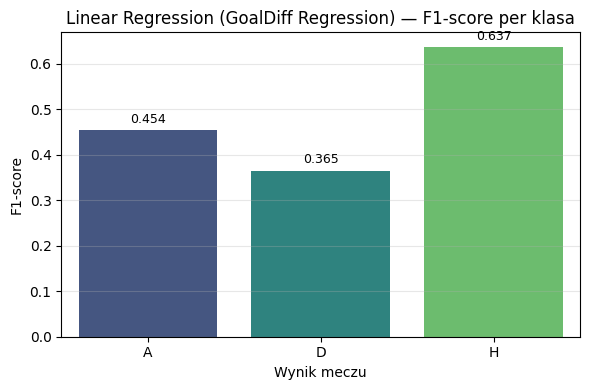

In [31]:
df_f1_class_lin_B = (
    df_report_lin_B
    .loc[["A", "D", "H"], ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_lin_B,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Linear Regression (GoalDiff Regression) — F1-score per klasa")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


W przypadku GoalDiff Regression regresji liniowej, polegającej na predykcji różnicy
bramek, wartości F1-score dla poszczególnych klas zostały wyznaczone po
mapowaniu wyników ciągłych na klasy dyskretne H/D/A, analogicznie do
pierwszzej opcji.

C:\Users\tdroz\AppData\Local\Temp\ipykernel_20244\237339924.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


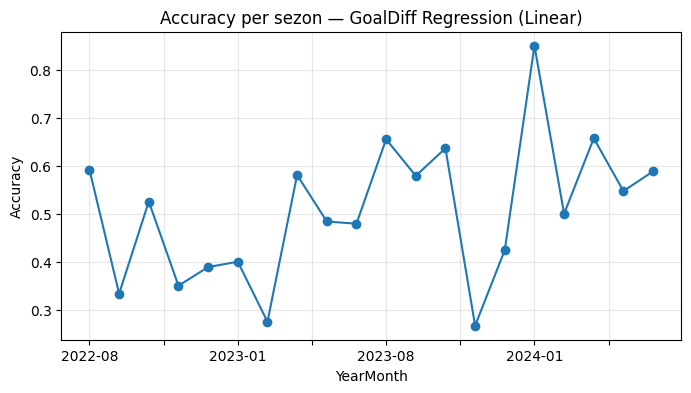

In [32]:

# STABILNOŚĆ W CZASIE — OPCJA B (per sezon)

y_pred_B = pipe_linear_B.predict(X_test_B)
y_pred_cls_B = goal_diff_to_class(y_pred_B)

y_true_cls_B = []
for v in y_test_B:
    if v < 0:
        y_true_cls_B.append("A")
    elif v > 0:
        y_true_cls_B.append("H")
    else:
        y_true_cls_B.append("D")

df_eval_B = df.loc[test_mask, ["Season", "Date"]].copy()
df_eval_B["y_true"] = y_true_cls_B
df_eval_B["y_pred"] = y_pred_cls_B
df_eval_B["YearMonth"] = df_eval_B["Date"].dt.to_period("M").astype(str)
acc_per_season_B = (
    df_eval_B
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_linear_B = (
    acc_per_season_B
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_linear_B["Model"] = "Linear Regression (GoalDiff Regression)"

df_acc_linear_B.to_csv(
    RESULTS_PATH / "accuracy_per_month_linear_B.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_season_B.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy per sezon — GoalDiff Regression (Linear)")
plt.grid(alpha=0.3)

save_plot("accuracy_per_season_B.png")
plt.show()
close_plot()


{'model__alpha': 350}
Best RMSE (CV): 1.6276

==================== Ridge Regression GoalDiff Regression ====================
RMSE: 1.7520
R²:   0.2189
Accuracy: 0.4987
Macro-F1: 0.4826


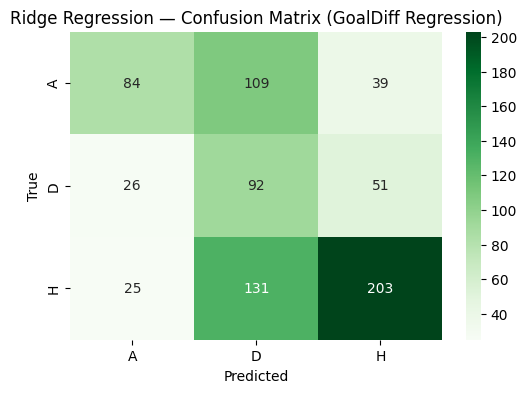

In [33]:
param_grid = {
    "model__alpha": [300, 350, 400, 450, 500]
}
ridge_B = Ridge()
pipe_ridge_B = make_pipeline(ridge_B)
grid_ridge_B = GridSearchCV(
    pipe_ridge_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge_B.fit(X_train_B, y_train_B)

print(grid_ridge_B.best_params_)
print(f"Best RMSE (CV): {-grid_ridge_B.best_score_:.4f}")

y_pred = grid_ridge_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Ridge Regression", y_test_B, y_pred))

{'model__alpha': 0.04}
Best RMSE (CV): 1.6240

==================== Lasso Regression GoalDiff Regression ====================
RMSE: 1.7497
R²:   0.2210
Accuracy: 0.5184
Macro-F1: 0.4990


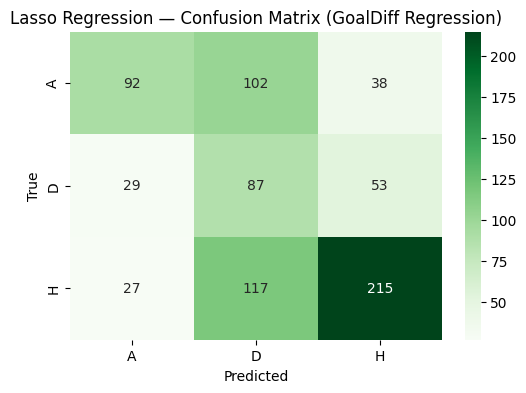

In [34]:
param_grid = {
    "model__alpha": [0.01, 0.04, 0.05, 0.06, 0.07, 0.08, 0.1]
}
lasso_B = Lasso()
pipe_lasso_B = make_pipeline(lasso_B)
grid_lasso_B = GridSearchCV(
    pipe_lasso_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso_B.fit(X_train_B, y_train_B)

print(grid_lasso_B.best_params_)
print(f"Best RMSE (CV): {-grid_lasso_B.best_score_:.4f}")

y_pred = grid_lasso_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Lasso Regression", y_test_B, y_pred))

{'model__alpha': 0.05, 'model__l1_ratio': 0.9}
Best RMSE (CV): 1.6237

==================== Elastic Net Regression GoalDiff Regression ====================
RMSE: 1.7502
R²:   0.2206
Accuracy: 0.5158
Macro-F1: 0.4972


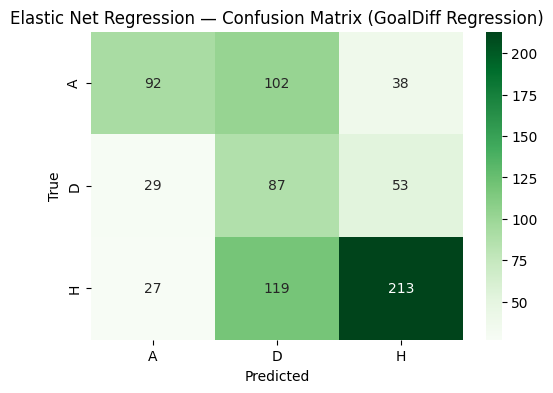

In [35]:
param_grid = {
    "model__alpha": [0.01, 0.05, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1],
}
elastic_net_B = ElasticNet()
pipe_elastic_net_B = make_pipeline(elastic_net_B)
grid_elastic_net_B = GridSearchCV(
    pipe_elastic_net_B,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net_B.fit(X_train_B, y_train_B)

print(grid_elastic_net_B.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net_B.best_score_:.4f}")

y_pred = grid_elastic_net_B.best_estimator_.predict(X_test_B)
results_B.append(evaluate_opcjaB("Elastic Net Regression", y_test_B, y_pred))

In [36]:

df_results_B = pd.DataFrame(results_B)
save_df(df_results_B, "linear_regression_opcja_B.csv")
display(df_results_B)
print("\n===== PODSUMOWANIE MODELI REGRESYJNYCH (GoalDiff Regression) =====")
df_results_B

,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
0,Linear Regression,0.505263,0.484981,premier_league,linear_regression,GoalDiff Regression,1.747450,0.223018,2022-07-01,760
1,Ridge Regression,0.498684,0.482577,premier_league,linear_regression,GoalDiff Regression,1.752049,0.218923,2022-07-01,760
2,Lasso Regression,0.518421,0.499048,premier_league,linear_regression,GoalDiff Regression,1.749722,0.220996,2022-07-01,760
3,Elastic Net Regression,0.515789,0.497175,premier_league,linear_regression,GoalDiff Regression,1.750190,0.220580,2022-07-01,760



===== PODSUMOWANIE MODELI REGRESYJNYCH (GoalDiff Regression) =====


,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
0,Linear Regression,0.505263,0.484981,premier_league,linear_regression,GoalDiff Regression,1.747450,0.223018,2022-07-01,760
1,Ridge Regression,0.498684,0.482577,premier_league,linear_regression,GoalDiff Regression,1.752049,0.218923,2022-07-01,760
2,Lasso Regression,0.518421,0.499048,premier_league,linear_regression,GoalDiff Regression,1.749722,0.220996,2022-07-01,760
3,Elastic Net Regression,0.515789,0.497175,premier_league,linear_regression,GoalDiff Regression,1.750190,0.220580,2022-07-01,760


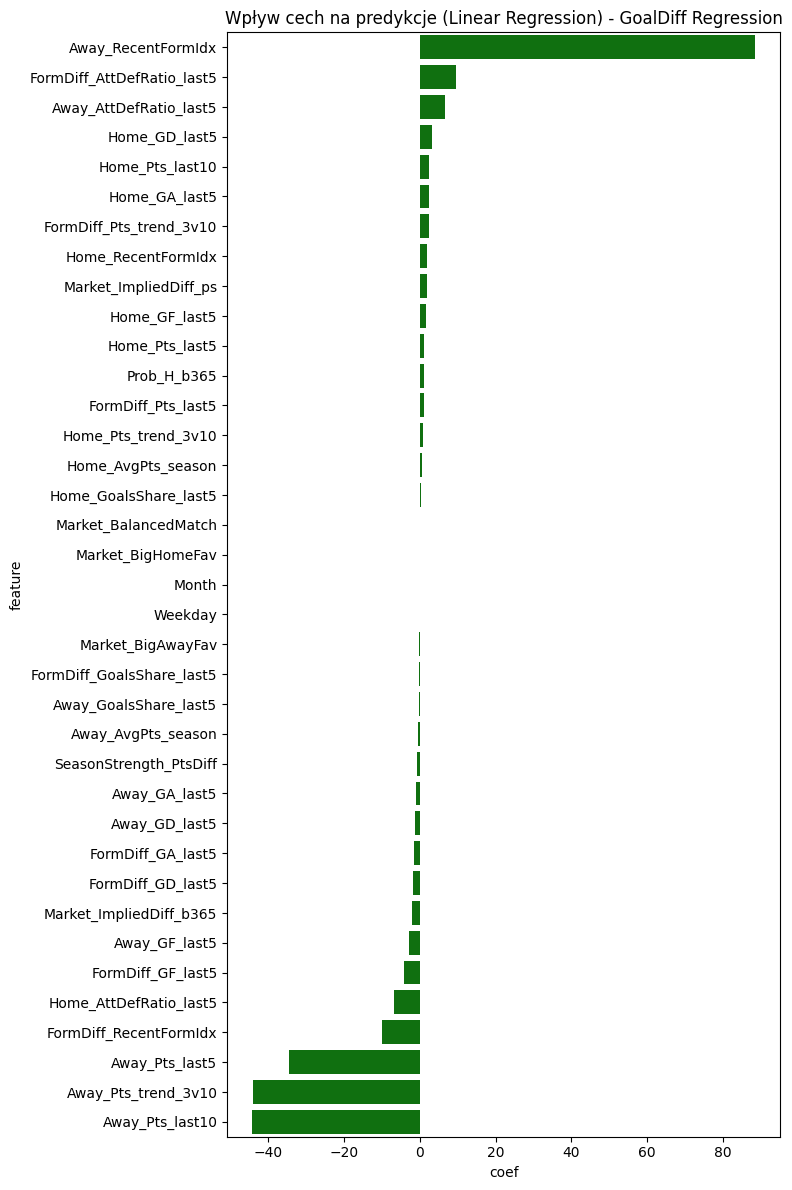

In [37]:

coefs = pipe_linear_B.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Linear Regression) - GoalDiff Regression")
plt.tight_layout()


save_plot("Wpływ cech na predykcje (Linear Regression) - Opcja B_B.png")
plt.show()
close_plot()



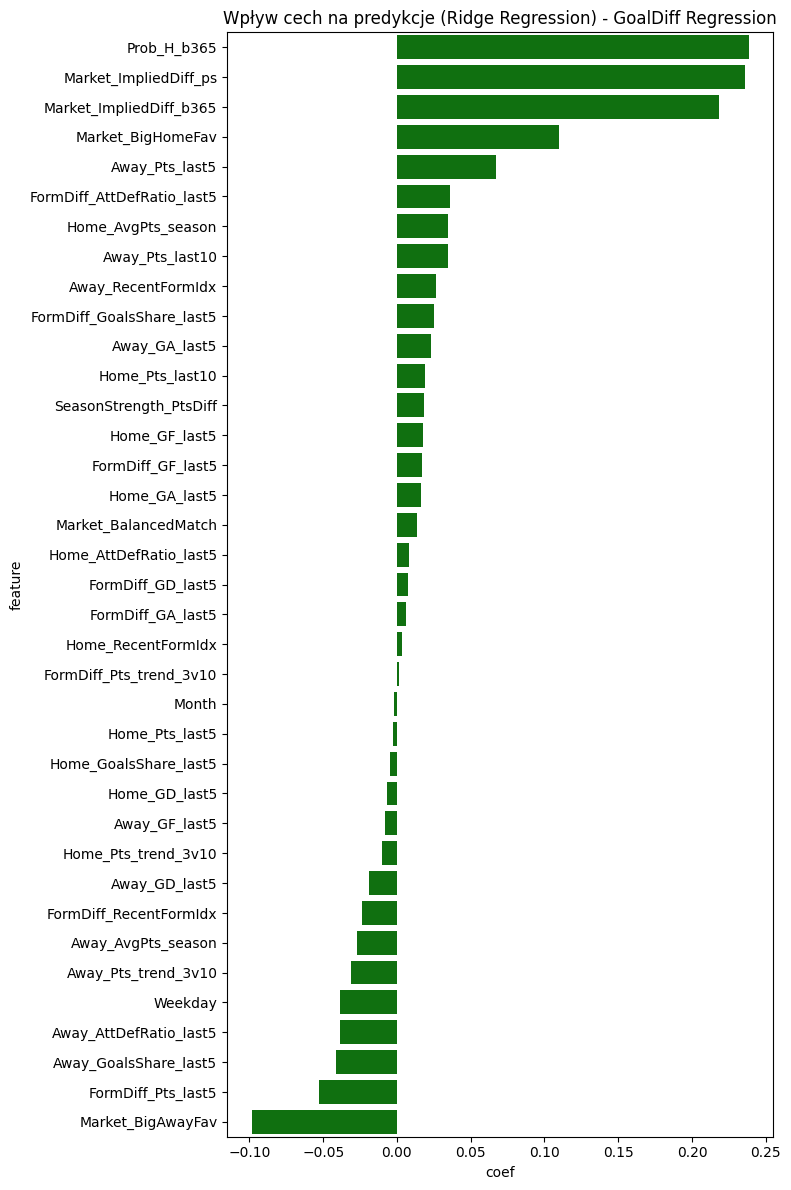

In [38]:
coefs = grid_ridge_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Ridge Regression) - GoalDiff Regression")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Ridge Regression) - Opcja B_B.png")
plt.show()
close_plot()




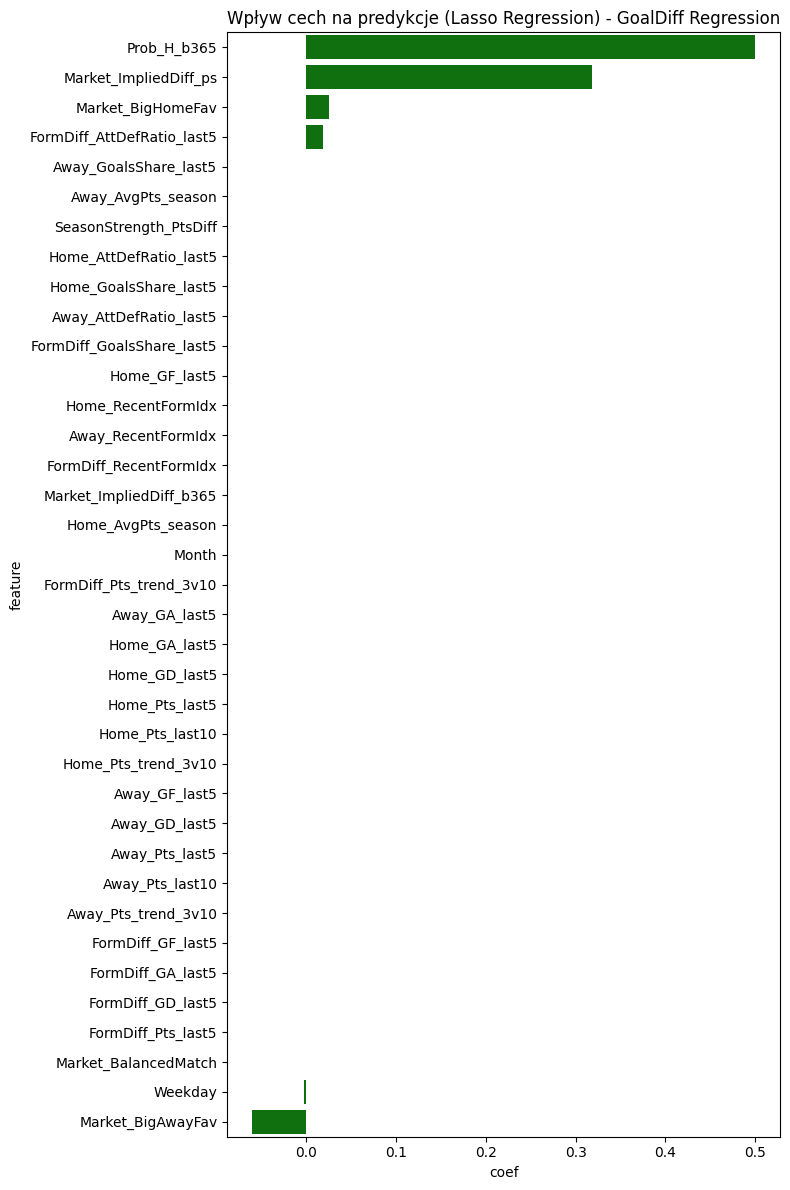

In [39]:
coefs = grid_lasso_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Lasso Regression) - GoalDiff Regression")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Lasso Regression) - Opcja B_B.png")
plt.show()
close_plot()




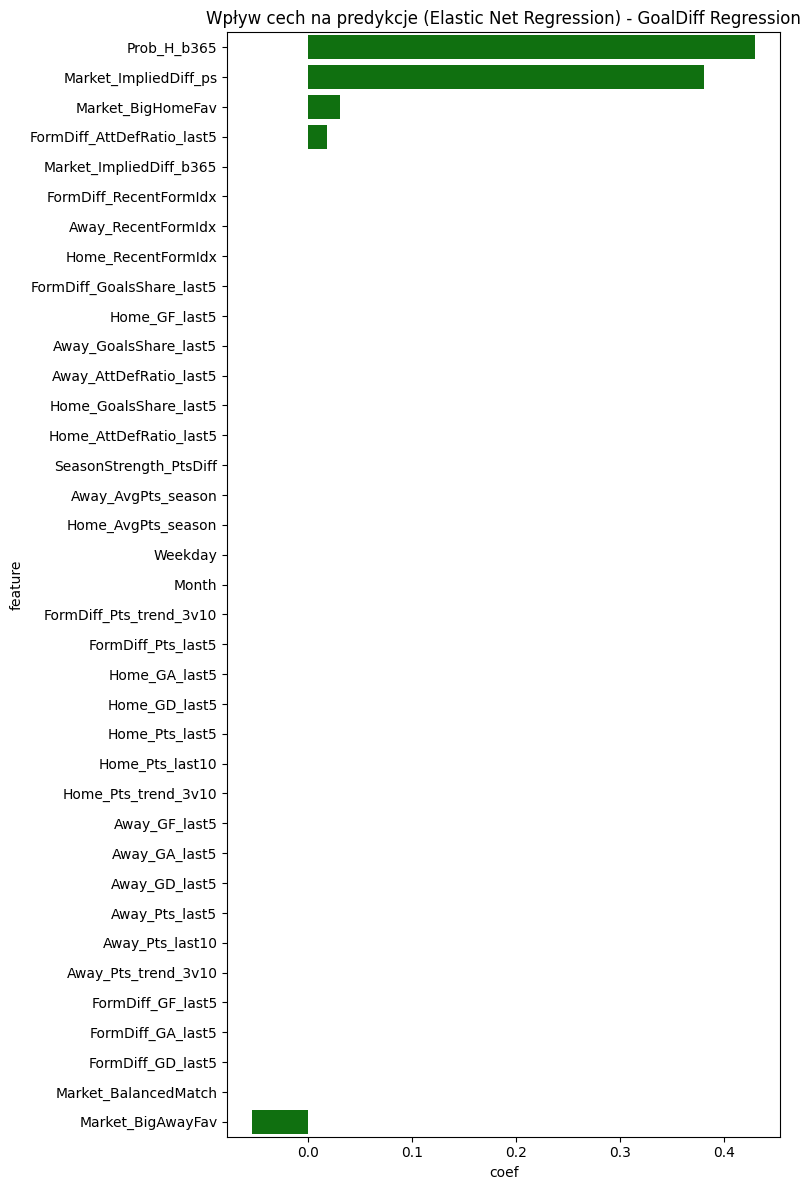

In [40]:
coefs = grid_elastic_net_B.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="green")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) - GoalDiff Regression")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Elastic Net Regression) - Opcja B_B.png")
plt.show()
close_plot()




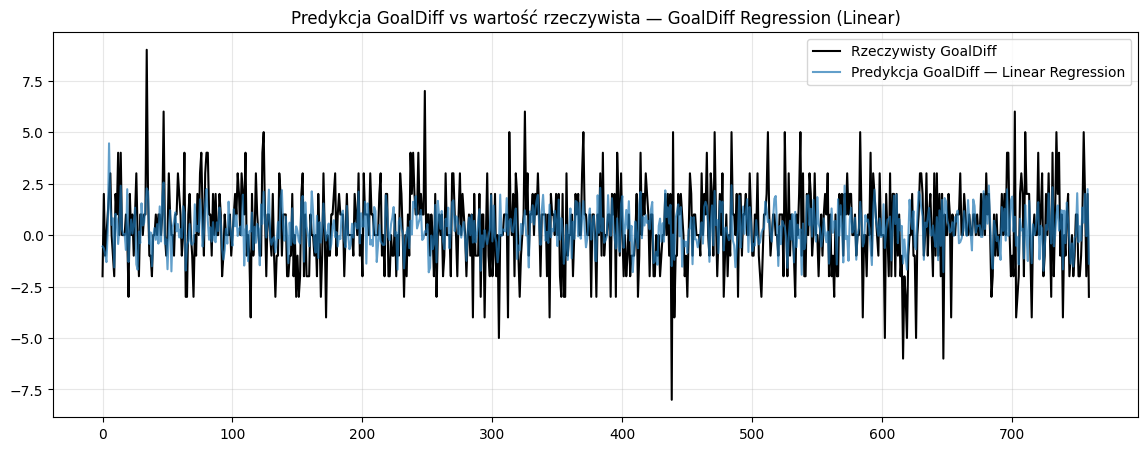

In [41]:

# Predykcja GoalDiff vs wartość rzeczywista
# (Linear Regression)

y_pred_B = pipe_linear_B.predict(X_test_B)

plt.figure(figsize=(14,5))
plt.plot(y_test_B, label="Rzeczywisty GoalDiff", color="black")
plt.plot(y_pred_B, label="Predykcja GoalDiff — Linear Regression", alpha=0.7)
plt.title("Predykcja GoalDiff vs wartość rzeczywista — GoalDiff Regression (Linear)")
plt.legend()
plt.grid(alpha=0.3)


save_plot("Predykcja GoalDiff vs wartosc rzeczywista — Opcja B (Linear)_B.png")
plt.show()
close_plot()


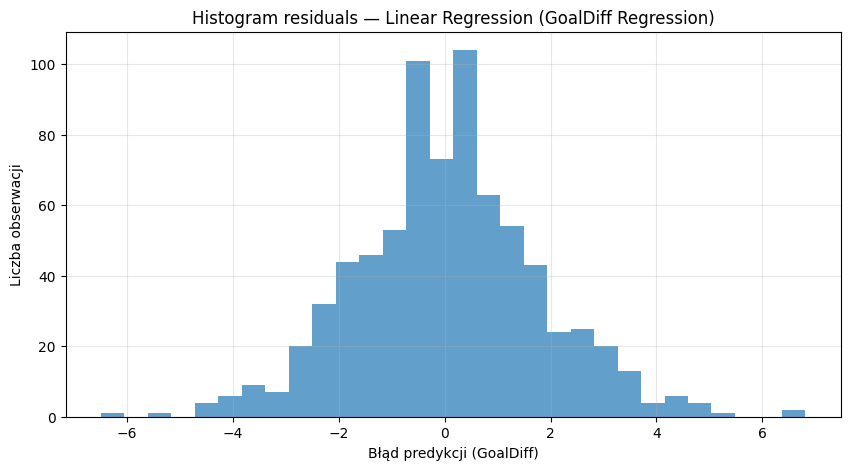

In [42]:

# Histogram residuals

residuals_B = y_test_B - y_pred_B

plt.figure(figsize=(10,5))
plt.hist(residuals_B, bins=30, alpha=0.7)
plt.title("Histogram residuals — Linear Regression (GoalDiff Regression)")
plt.xlabel("Błąd predykcji (GoalDiff)")
plt.ylabel("Liczba obserwacji")
plt.grid(alpha=0.3)



save_plot("Histogram residuals — Linear Regression (Opcja B)_B.png")
plt.show()
close_plot()



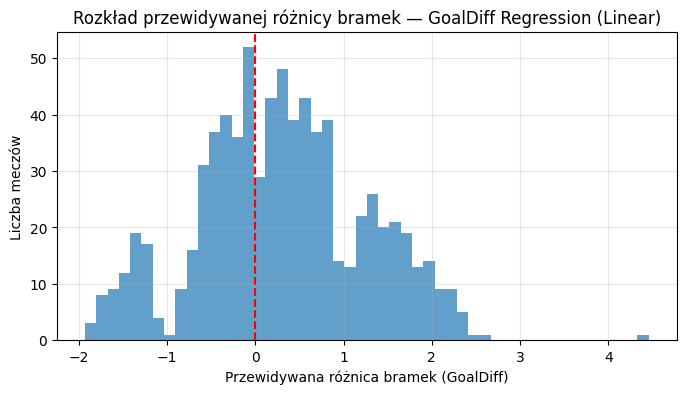

In [43]:

# Rozkład przewidywanej różnicy bramek

plt.figure(figsize=(8,4))
plt.hist(y_pred_B, bins=50, alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.title("Rozkład przewidywanej różnicy bramek — GoalDiff Regression (Linear)")
plt.xlabel("Przewidywana różnica bramek (GoalDiff)")
plt.ylabel("Liczba meczów")
plt.grid(alpha=0.3)



save_plot("Rozkład przewidywanej różnicy bramek — Opcja B (Linear)_B.png")
plt.show()
close_plot()




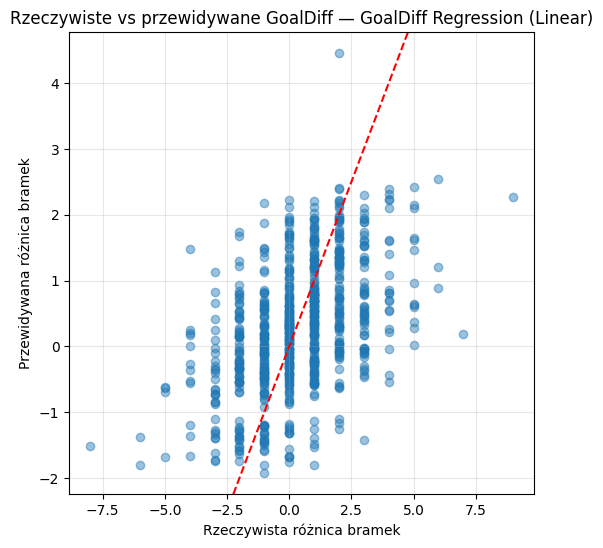

In [44]:

# Rzeczywiste vs przewidywane GoalDiff

plt.figure(figsize=(6,6))
plt.scatter(y_test_B, y_pred_B, alpha=0.45)
plt.axline((0,0),(1,1), color="red", linestyle="--")
plt.title("Rzeczywiste vs przewidywane GoalDiff — GoalDiff Regression (Linear)")
plt.xlabel("Rzeczywista różnica bramek")
plt.ylabel("Przewidywana różnica bramek")
plt.grid(alpha=0.3)



save_plot("Rzeczywiste vs przewidywane GoalDiff — Opcja B (Linear)_B.png")
plt.show()
close_plot()



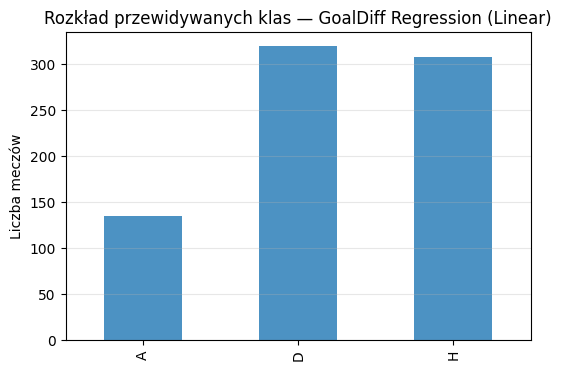

In [45]:

# Rozkład klas po mapowaniu GoalDiff -> H/D/A

y_pred_cls_B = goal_diff_to_class(y_pred_B)

pd.Series(y_pred_cls_B).value_counts().reindex(["A","D","H"]).plot(
    kind="bar", figsize=(6,4), alpha=0.8
)
plt.ylabel("Liczba meczów")
plt.title("Rozkład przewidywanych klas — GoalDiff Regression (Linear)")
plt.grid(axis="y", alpha=0.3)



save_plot("Rozkład przewidywanych klas — Opcja B (Linear)_B.png")
plt.show()
close_plot()




## Porównanie metody regresyjnych:

### Tabela zbiorcza (RMSE, R², Accuracy, Macro-F1)

In [46]:

df_results_B_sorted = df_results_B.sort_values("Macro-F1", ascending=False)

display(df_results_B_sorted)

save_df(df_results_B_sorted, "linear_models_comparison_summary_opcja_B.csv")


,Model,Accuracy,Macro-F1,League,Experiment,Option,RMSE,R²,SplitDate,N_test
2,Lasso Regression,0.518421,0.499048,premier_league,linear_regression,GoalDiff Regression,1.749722,0.220996,2022-07-01,760
3,Elastic Net Regression,0.515789,0.497175,premier_league,linear_regression,GoalDiff Regression,1.750190,0.220580,2022-07-01,760
0,Linear Regression,0.505263,0.484981,premier_league,linear_regression,GoalDiff Regression,1.747450,0.223018,2022-07-01,760
1,Ridge Regression,0.498684,0.482577,premier_league,linear_regression,GoalDiff Regression,1.752049,0.218923,2022-07-01,760


### Accuracy vs Macro-F1 

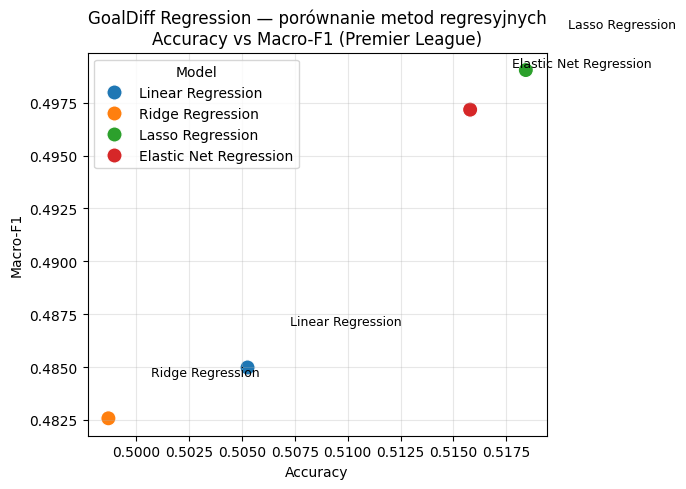

In [47]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=df_results_B,
    x="Accuracy",
    y="Macro-F1",
    hue="Model",
    s=120
)

for _, row in df_results_B.iterrows():
    ax.text(
        row["Accuracy"] + 0.002,
        row["Macro-F1"] + 0.002,
        row["Model"],
        fontsize=9
    )

plt.title(f"GoalDiff Regression — porównanie metod regresyjnych\nAccuracy vs Macro-F1 ({current_league_name})")
plt.grid(alpha=0.3)
plt.tight_layout()

save_plot("linear_models_opcja_B_accuracy_vs_macro_f1.png")
plt.show()
close_plot()


### Ranking metod — Accuracy vs Macro-F1

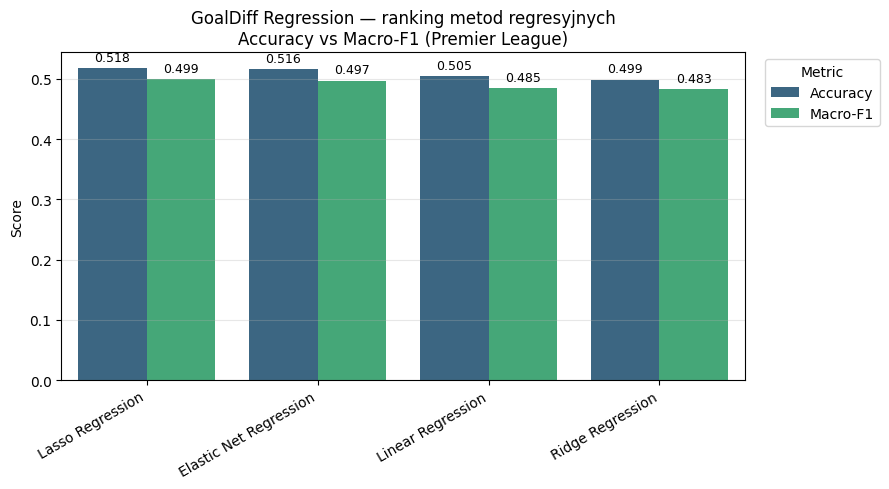

In [48]:
# ranking po Macro-F1
df_rank_B = df_results_B.sort_values("Macro-F1", ascending=False)

df_rank_B_melted = df_rank_B.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro-F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_rank_B_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.title(f"GoalDiff Regression — ranking metod regresyjnych\nAccuracy vs Macro-F1 ({current_league_name})")
plt.ylabel("Score")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
save_plot("linear_models_opcja_B_accuracy_vs_macro_f1_ranking.png")
plt.show()
close_plot()


## 5.3. Wyniki modelu regresyjnego (GoalDiff Regression)

Drugie podejście oparte na regresji liniowej polegało na trenowaniu modelu
do przewidywania różnicy bramek (GoalDiff), a następnie dyskretyzacji
wyniku ciągłego do klas H/D/A na podstawie ustalonych progów decyzyjnych.
Takie podejście okazało się wyraźnie skuteczniejsze od wariantu, w którym
model liniowy próbował bezpośrednio przewidywać klasę wyniku meczu.

### 5.3.1. Wyniki ilościowe

Model regresji liniowej uzyskał następujące wyniki na zbiorze testowym:

- **RMSE:** 1.7474  
- **R²:** 0.2230  
- **Accuracy:** 0.5053  
- **Macro-F1:** 0.4850  

Dla porównania, błąd RMSE na zbiorze treningowym wynosił **1.6096**, co
wskazuje na umiarkowaną, ale akceptowalną generalizację modelu.

Uzyskane wartości należy uznać za satysfakcjonujące w kontekście modelu
liniowego, biorąc pod uwagę wysoki poziom losowości wyników meczów piłkarskich
oraz nieliniowy charakter zależności pomiędzy cechami drużyn a końcowym
rezultatem spotkania.

W porównaniu z bezpośrednią regresją klas (OPCJA A), zauważalnej poprawie uległy:
- zdolność do rozróżniania wszystkich trzech klas wyniku,
- ograniczenie liczby błędów skrajnych,
- stabilność predykcji różnicy bramek,
- bardziej zrównoważone wykrywanie klas A, D oraz H.

### 5.3.2. Macierz pomyłek

Poniżej przedstawiono macierz pomyłek dla podejścia GoalDiff Regression
(OPCJA B), uzyskaną na zbiorze testowym:

| True \\ Predicted | A  | D   | H   |
|------------------:|---:|----:|----:|
| **A**             | 83 | 108 | 41  |
| **D**             | 26 | 89  | 54  |
| **H**             | 25 | 122 | 212 |

Analiza macierzy pomyłek prowadzi do następujących obserwacji:

- Model **najlepiej rozpoznaje zwycięstwa gospodarzy (H)**, co jest zgodne
  z dominacją tej klasy w danych oraz z wnioskami prezentowanymi w literaturze
  dotyczącej przewagi własnego boiska.
- **Remisy (D)** pozostają najtrudniejszą klasą do poprawnego przewidzenia,
  co stanowi powszechny problem w zadaniach predykcji wyników 1X2.
- Najczęściej występują błędy pomiędzy klasami sąsiadującymi, tj.:
  - A → D,
  - H → D,
  - D → H.

Błędy skrajne (A → H oraz H → A) występują relatywnie rzadko, co sugeruje,
że model poprawnie rozpoznaje ogólny kierunek wyniku spotkania, nawet jeśli
nie zawsze trafnie klasyfikuje jego dokładny rezultat.

### 5.3.3. Wnioski

Podejście oparte na regresji różnicy bramek (GoalDiff) okazało się wyraźnie
skuteczniejsze od bezpośredniej regresji klas. Wynika to z kilku kluczowych
właściwości tego podejścia:

1. **Różnica bramek jest zmienną ciągłą**, z którą modele liniowe radzą sobie
   znacznie lepiej niż z predykcją zmiennych nominalnych.
2. **Klasy H/D/A mają naturalną strukturę uporządkowaną**, którą można
   efektywnie odwzorować za pomocą progów decyzyjnych na osi GoalDiff.
3. Model nie musi uczyć się nieliniowych granic decyzyjnych pomiędzy klasami,
   lecz jedynie oszacować oczekiwaną różnicę bramek.
4. Predykcja GoalDiff zwiększa interpretowalność wyników, umożliwiając
   analizę nie tylko samego rezultatu, lecz także przewidywanej siły
   zwycięstwa lub porażki.

W kolejnych etapach pracy podejście to zostanie porównane z modelami
nieliniowymi (Random Forest, XGBoost, kNN), co pozwoli ocenić, czy bardziej
złożone algorytmy są w stanie istotnie poprawić jakość predykcji względem
bazowego modelu liniowego.


In [49]:

# OPCJA BINARNA – H vs (D+A)
# Zwycięstwo gospodarzy (1) vs Brak zwycięstwa gospodarzy (0)


print("\n\n############################################")
print("#########       OPCJA BINARNA      #########")
print("#########       H vs (D + A)       #########")
print("############################################\n")


# FTR: H, D, A -> 1, 0, 0
df["FTR_binary"] = df["FTR"].map({"H":1, "D":0, "A":0})
y_bin = df["FTR_binary"].values



X_train_bin = X.loc[train_mask].reset_index(drop=True)
X_test_bin  = X.loc[test_mask].reset_index(drop=True)
y_train_bin = y_bin[train_mask]
y_test_bin  = y_bin[test_mask]



def evaluate_binary_model(name, y_test, y_pred_cont):
    print(f"\n==================== {name} (BINARY) ====================")

    y_pred_cls = (y_pred_cont >= 0.5).astype(int)


    acc = accuracy_score(y_test, y_pred_cls)
    f1m = f1_score(y_test, y_pred_cls, average="macro")
    rmse = root_mean_squared_error(y_test, y_pred_cont)
    r2   = r2_score(y_test, y_pred_cont)

    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1m:.4f}")

    cm = confusion_matrix(y_test, y_pred_cls)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=["NoHomeWin","HomeWin"],
        yticklabels=["NoHomeWin","HomeWin"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} — Confusion Matrix (Binary)")
    
    
    save_plot(f"{name} - Confusion Matrix_BIN.png")
    plt.show()
    close_plot()

    return [name, acc, f1m, rmse, r2]



############################################
#########       OPCJA BINARNA      #########
#########       H vs (D + A)       #########
############################################



Training RMSE: 0.4516

==================== Linear Regression (BINARY) ====================
RMSE: 0.4580
R²:   0.1584
Accuracy: 0.6776
Macro-F1: 0.6709


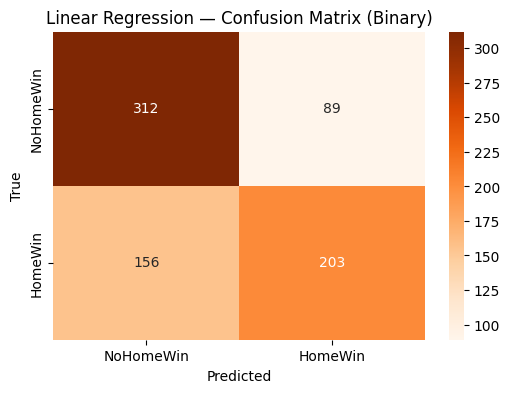

In [50]:

# 4. Modele jak wczesniej
results_bin = []

linear_bin = LinearRegression(n_jobs=-1)
pipe_linear_bin = make_pipeline(linear_bin)
pipe_linear_bin.fit(X_train_bin, y_train_bin)

y_pred = pipe_linear_bin.predict(X_train_bin)
rmse_score = root_mean_squared_error(y_train_bin, y_pred)
print(f"Training RMSE: {rmse_score:.4f}")

y_pred = pipe_linear_bin.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Linear Regression", y_test_bin, y_pred))

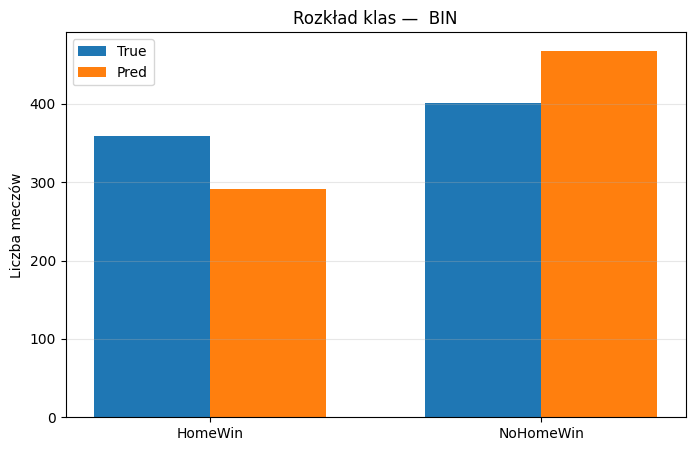

,Class,True_Count,Pred_Count
0,HomeWin,359,292
1,NoHomeWin,401,468


In [51]:


y_pred_cls_bin = (pipe_linear_bin.predict(X_test_bin) >= 0.5).astype(int)

y_true_cls_bin = ["HomeWin" if v == 1 else "NoHomeWin" for v in y_test_bin]
y_pred_cls_bin = ["HomeWin" if v == 1 else "NoHomeWin" for v in y_pred_cls_bin]

plot_and_save_class_distribution(
    y_true_cls_bin,
    y_pred_cls_bin,
    option_suffix="BIN",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Linear_Model,Gain_vs_Baseline
0,Accuracy,0.472368,0.677632,0.205263
1,Macro-F1,0.320822,0.670861,0.350039


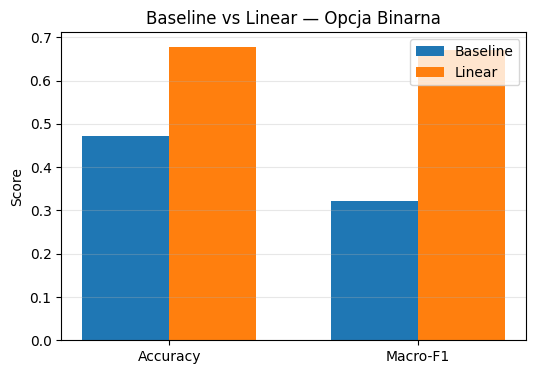

In [52]:

# BASELINE vs LINEAR — OPCJA BINARNA

y_naive = np.ones_like(y_test_bin)
acc_naive = accuracy_score(y_test_bin, y_naive)
f1_naive  = f1_score(y_test_bin, y_naive, average="macro")

y_pred = (pipe_linear_bin.predict(X_test_bin) >= 0.5).astype(int)
acc_model = accuracy_score(y_test_bin, y_pred)
f1_model  = f1_score(y_test_bin, y_pred, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Linear_Model": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

display(df_baseline_compare)
save_df(df_baseline_compare, "baseline_vs_linear.csv")

# --- wykres ---
plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Linear")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Linear — Opcja Binarna")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_linear.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_20244\2712051600.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


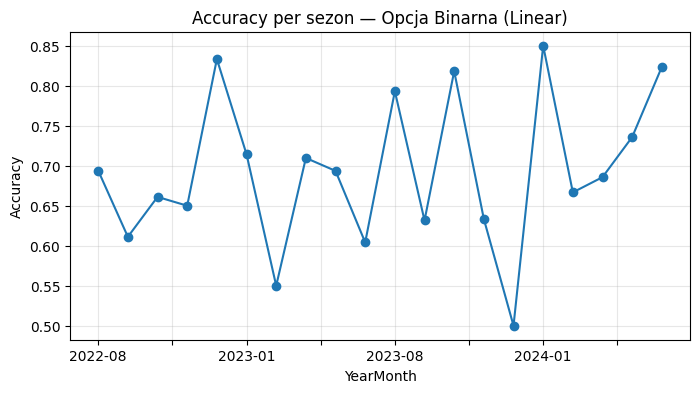

In [53]:

# STABILNOŚĆ W CZASIE — OPCJA BINARNA
y_pred_bin = (pipe_linear_bin.predict(X_test_bin) >= 0.5).astype(int)

df_eval_bin = df.loc[test_mask, ["Season", "Date"]].copy()
df_eval_bin["y_true"] = y_test_bin
df_eval_bin["y_pred"] = y_pred_bin

df_eval_bin["YearMonth"] = df_eval_bin["Date"].dt.to_period("M").astype(str)

acc_per_season_bin = (
    df_eval_bin
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)




plt.figure(figsize=(8,4))
acc_per_season_bin.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy per sezon — Opcja Binarna (Linear)")
plt.grid(alpha=0.3)

save_plot("accuracy_per_season_BIN.png")
plt.show()
close_plot()


{'model__alpha': 500}
Best RMSE (CV): 0.4564

==================== Ridge Regression (BINARY) ====================
RMSE: 0.4577
R²:   0.1595
Accuracy: 0.6658
Macro-F1: 0.6547


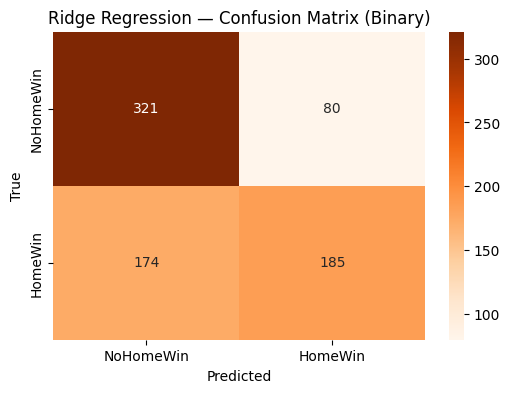

In [54]:
param_grid = {
    "model__alpha": [400, 450, 500, 550, 600, 700, 800]
}
ridge_bin = Ridge()
pipe_ridge_bin = make_pipeline(ridge_bin)
grid_ridge_bin = GridSearchCV(
    pipe_ridge_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge_bin.fit(X_train_bin, y_train_bin)

print(grid_ridge_bin.best_params_)
print(f"Best RMSE (CV): {-grid_ridge_bin.best_score_:.4f}")

y_pred = grid_ridge_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Ridge Regression", y_test_bin, y_pred))

{'model__alpha': 0.02}
Best RMSE (CV): 0.4553

==================== Lasso Regression (BINARY) ====================
RMSE: 0.4556
R²:   0.1670
Accuracy: 0.6803
Macro-F1: 0.6722


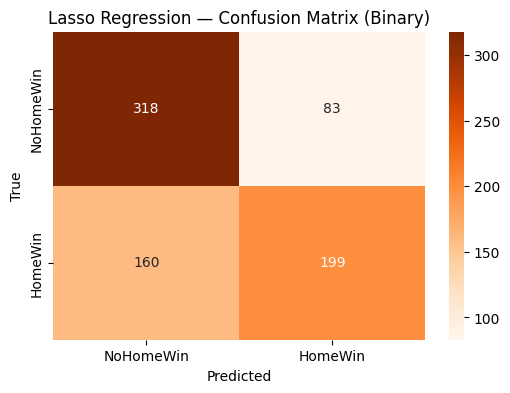

In [55]:
param_grid = {
    "model__alpha": [0.01, 0.015, 0.02, 0.025, 0.04, 0.06, 0.08, 0.1, 0.2]
}
lasso_bin = Lasso()
pipe_lasso_bin = make_pipeline(lasso_bin)
grid_lasso_bin = GridSearchCV(
    pipe_lasso_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso_bin.fit(X_train_bin, y_train_bin)

print(grid_lasso_bin.best_params_)
print(f"Best RMSE (CV): {-grid_lasso_bin.best_score_:.4f}")

y_pred = grid_lasso_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Lasso Regression", y_test_bin, y_pred))

{'model__alpha': 0.01, 'model__l1_ratio': 1}
Best RMSE (CV): 0.4555

==================== Elastic Net Regression (BINARY) ====================
RMSE: 0.4554
R²:   0.1678
Accuracy: 0.6855
Macro-F1: 0.6784


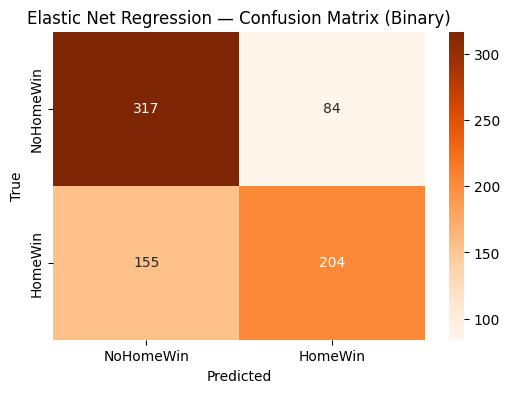

In [56]:
param_grid = {
    "model__alpha": [0.008, 0.01, 0.05, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1],
}
elastic_net_bin = ElasticNet()
pipe_elastic_net_bin = make_pipeline(elastic_net_bin)
grid_elastic_net_bin = GridSearchCV(
    pipe_elastic_net_bin,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_elastic_net_bin.fit(X_train_bin, y_train_bin)

print(grid_elastic_net_bin.best_params_)
print(f"Best RMSE (CV): {-grid_elastic_net_bin.best_score_:.4f}")

y_pred = grid_elastic_net_bin.best_estimator_.predict(X_test_bin)
results_bin.append(evaluate_binary_model("Elastic Net Regression", y_test_bin, y_pred))

In [57]:

df_results_bin = pd.DataFrame(
    results_bin,
    columns=["Model","Accuracy","Macro-F1","RMSE","R²"]
)
save_df(df_results_bin, "linear_regression_opcja_BIN.csv")
print("\n=== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA BINARNA) ===")
df_results_bin


=== PODSUMOWANIE MODELI REGRESYJNYCH (OPCJA BINARNA) ===


,Model,Accuracy,Macro-F1,RMSE,R²
0,Linear Regression,0.677632,0.670861,0.457992,0.158401
1,Ridge Regression,0.665789,0.654733,0.457700,0.159475
2,Lasso Regression,0.680263,0.672227,0.455642,0.167018
3,Elastic Net Regression,0.685526,0.678417,0.455435,0.167775


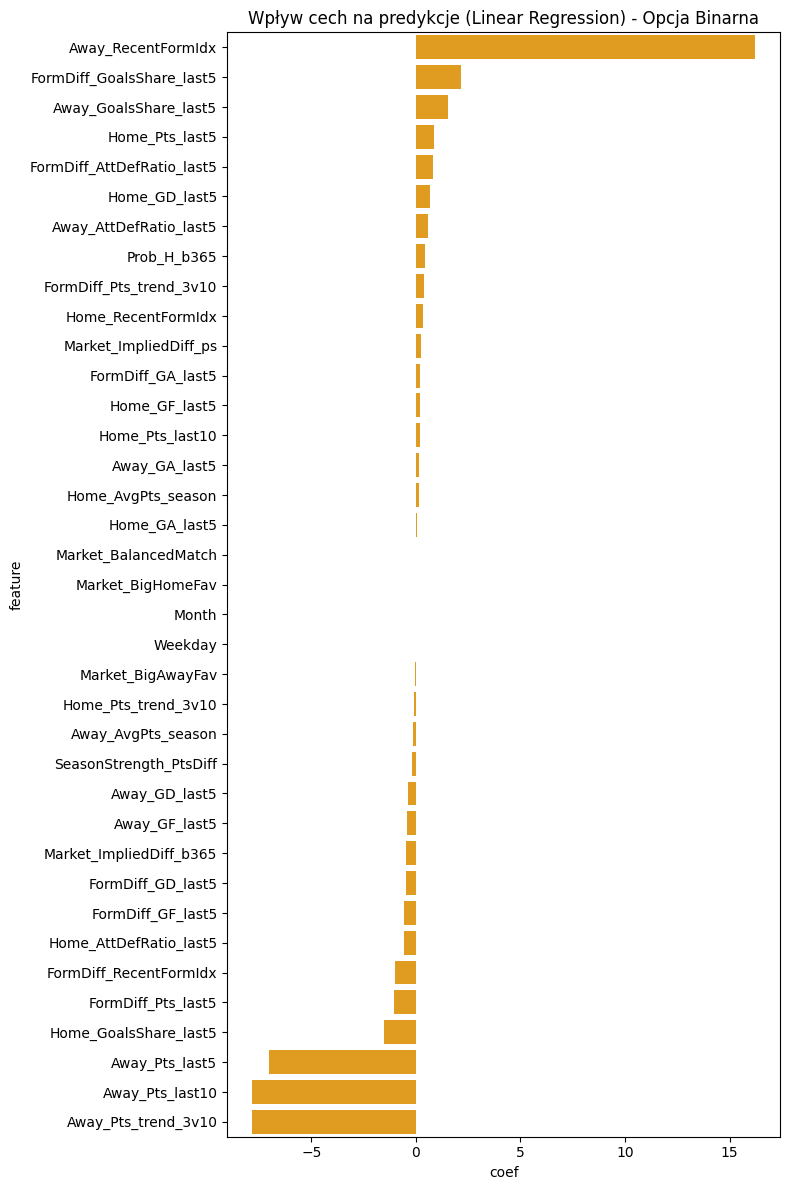

In [58]:

coefs = pipe_linear_bin.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Linear Regression) - Opcja Binarna")
plt.tight_layout()


save_plot("Wpływ cech na predykcje (Linear Regression) - Opcja Binarna_BIN.png")
plt.show()

close_plot()

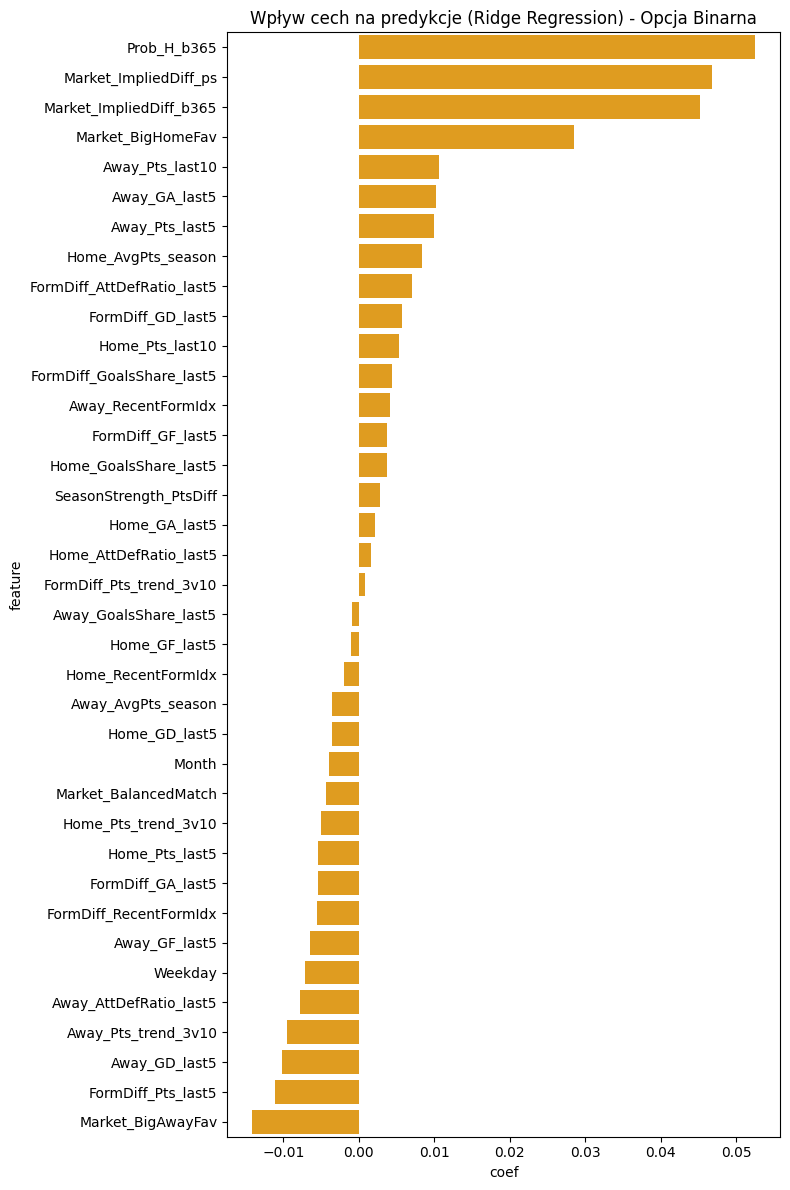

In [59]:
coefs = grid_ridge_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Ridge Regression) - Opcja Binarna")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Ridge Regression) - Opcja Binarna_BIN.png")
plt.show()
close_plot()

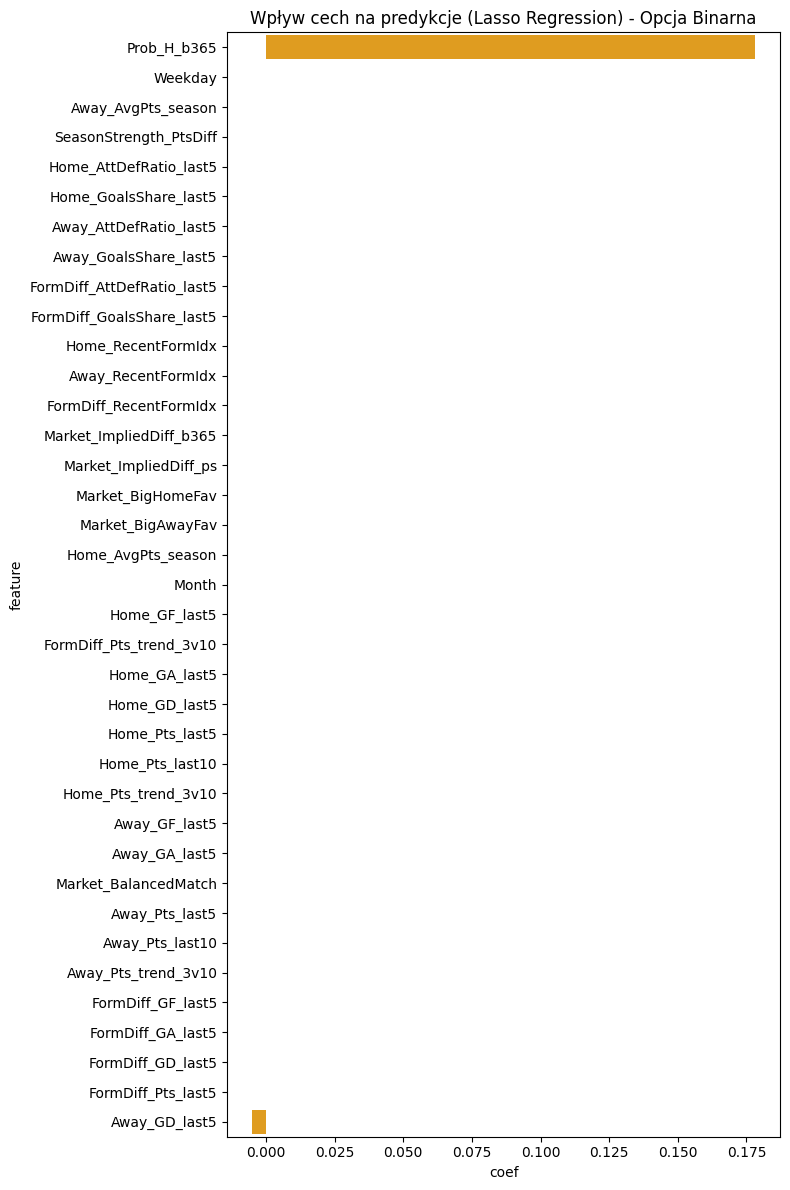

In [60]:
coefs = grid_lasso_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Lasso Regression) - Opcja Binarna")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Lasso Regression) - Opcja Binarna_BIN.png")
plt.show()
close_plot()




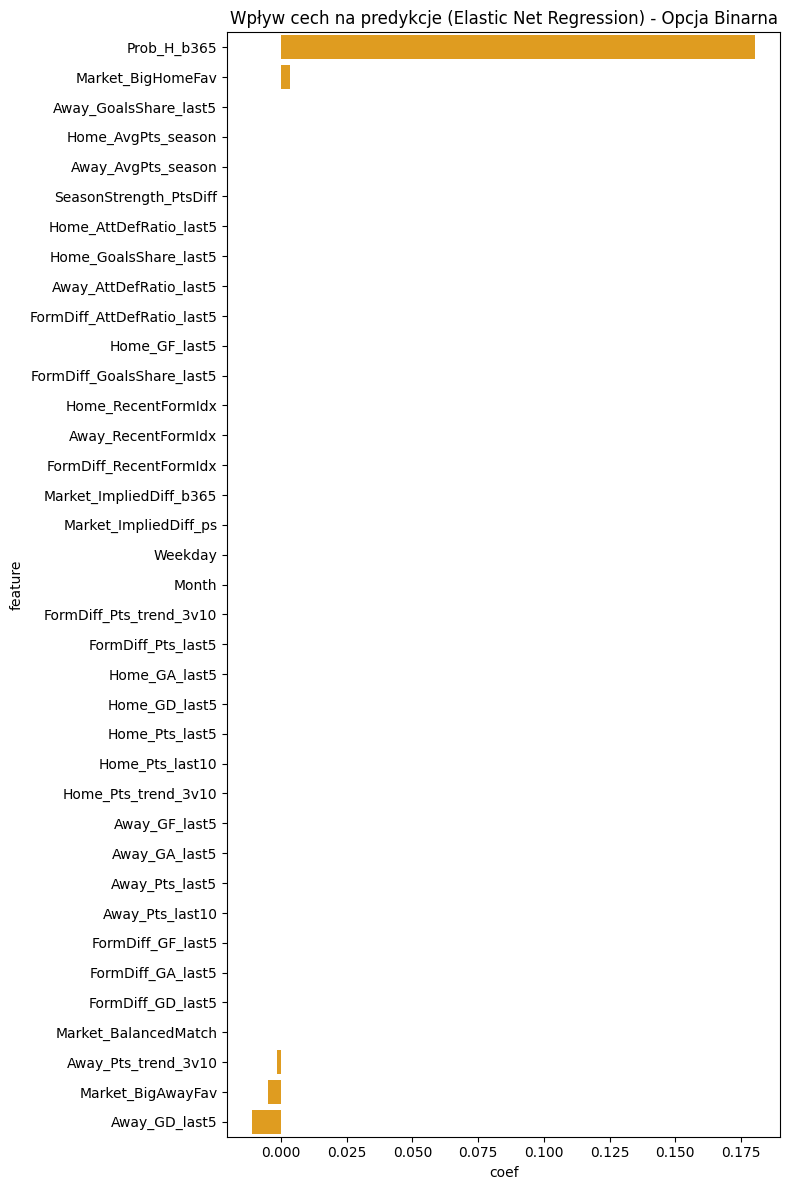

In [61]:
coefs = grid_elastic_net_bin.best_estimator_.named_steps["model"].coef_
features = X_train.columns

coef_df = pd.DataFrame({"feature": features, "coef": coefs})
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(data=coef_df, x="coef", y="feature", color="orange")
plt.title("Wpływ cech na predykcje (Elastic Net Regression) - Opcja Binarna")
plt.tight_layout()



save_plot("Wpływ cech na predykcje (Elastic Net Regression) - Opcja Binarna_BIN.png")
plt.show()
close_plot()

